In [3]:
#nothing changes with inVitro Origc cause everythingis 0 so nothing can be used to make stuff
fn = 'example\presPars.txt'
#'parsLoop1.txt'zzzz
# 'parsExtrinsic.txt' 
#'parsNewErything.txt' #'parsEverything.txt' #
#'parsLoop2InVivo.txt' # 'parsLoopInVitroMod.txt'
nameFromTextFile = fn
with open(fn) as file:
    lns = file.readlines()
konstants = [x.split(' ')[0] for x in lns if x != '\n']
print('presorted:', konstants)
for k in range(len(konstants)):
    if ":" in konstants[k]:
        konstants[k] = konstants[k].replace(":", "_")
    if "[" in konstants[k]:
        konstants[k] = konstants[k].replace("[", "")
    if "]" in konstants[k]:
        konstants[k] = konstants[k].replace("]", "")

print("presoreted, syntax change:", konstants)
v = [x.split(' ')[2].rstrip('\n') for x in lns if x != '\n']
lookup = dict(zip(konstants,v))
# print('lookup', lookup)


konstantsSorted = konstants
konstantsSorted.sort()
# ksorted = k.sort()
print('sorted:', konstantsSorted)
# print("ksorted", ksorted)

presorted: ['ICx', 'ICy', 'ICx:y', 'ka', 'kb', 'x', 'y', 'x:y']
presoreted, syntax change: ['ICx', 'ICy', 'ICx_y', 'ka', 'kb', 'x', 'y', 'x_y']
sorted: ['ICx', 'ICx_y', 'ICy', 'ka', 'kb', 'x', 'x_y', 'y']


In [2]:
fn = 'eqnsL1.txt' #'eqsExtrinsic.txt' #'eqsNew.txt' #'Loop2ReplaceFromIpad.txt' #'eqnsInputsConsumedLoop1.txt'

varMat = []
var = []
err = []
eqs = []
newTerms = []

with open(fn) as file:
    lines = file.readlines()
#     print(lines)

for i, line in enumerate(lines): # parse out names of equations (<- =)
    if line.lstrip().startswith(r'\frac{'):
        s = line.split(' ')
#         print('s: ', s)
# matrix variable names keep the [] for legibility
        tmpMat = s[0].split('{d')
        varMat.append(tmpMat[1][:-1].strip()) # var names list
        
# remove the [] around the variable name for SPICE, only keep in input text 
        tmp = s[0].split('{d[')[1].split(']')[0]
#         print(type(tmp)) # <class 'list'>
#         print('temp: ', tmp.strip())
        var.append(tmp.strip()) # var names list
        
    else:
        print('Incorrect format: ', line)
        err.append(i)
        
print('var = ', var)
print('varMat = ', varMat)

var =  ['TFPI', 'FXa:TFPI', 'TF:FVIIa:FXa:TFPI', 'FXa', 'TF:FVIIa', 'TF:FVIIa:FXa']
varMat =  ['[TFPI]', '[FXa:TFPI]', '[TF:FVIIa:FXa:TFPI]', '[FXa]', '[TF:FVIIa]', '[TF:FVIIa:FXa]']


In [3]:
#replacing the : for _ to match SPICE allowed symbols for variable names
for i in range(len(var)):
    if ":" in var[i]:
        var[i] = var[i].replace(":", "_")

print(var)


['TFPI', 'FXa_TFPI', 'TF_FVIIa_FXa_TFPI', 'FXa', 'TF_FVIIa', 'TF_FVIIa_FXa']


In [4]:
# dont think we need this if we keeping the easier terminology
# for i in range(len(varMat)):
#     if ":" in var[i]:
#         varMat[i] = varMat[i].replace(":", "_")

# print(varMat)


In [5]:
# for i in err: #remove any wrongly formatted lines
#     del lines[i]

# for l in lines: # parse out equation (= ->)
#     tmp = l.split(' ')[2:]
# #     print('lsplit: ', tmp)
#     tmp[-1] = tmp[-1].rstrip()#[:-1]
# #     print(strtmp)
# #     print(type(tmp[-1])) #<class 'str'>
#     eqs.append(tmp) # terms
#     print("".join(str(tmp)))
    


#     tmp[-1] = tmp[-1].rstrip()#[:-1]
# #     print(tmp[-1])
# #     print(type(tmp[-1])) #<class 'str'>
#     eqs.append(tmp) # terms
#     print("".join(str(tmp)))

In [6]:
for i in err: #remove any wrongly formatted lines
    del lines[i]

for l in lines: # parse out equation (= ->)
    tmp = l.split(' ')[2:]
    
#     print('lsplit: ', tmp)
    cleaned_terms = []
    for t in tmp:
        if ':' in t:
            t = t.replace(":", "_")
        t = t.strip()  # Remove any extra whitespaces or newlines
        if t:  # add any non-empty strings
            cleaned_terms.append(t)
            
    eqs.append(cleaned_terms)
    print("".join(str(cleaned_terms)))

['-k47[TF_FVIIa_FXa][TFPI]', '+k48[TF_FVIIa_FXa_TFPI]', '-k45[FXa][TFPI]', '+k46[FXa_TFPI]']
['k45[FXa][TFPI]', '-k46[FXa_TFPI]', '-k49[TF_FVIIa][FXa_TFPI]']
['k49[TF_FVIIa][FXa_TFPI]', '+k47[TF_FVIIa_FXa][TFPI]', '-k48[TF_FVIIa_FXa_TFPI]']
['-k45[FXa][TFPI]', '+k46[FXa_TFPI]', '+k16[TF_FVIIa_FXa]', '-k15[FXa][TF_FVIIa]']
['-k49[TF_FVIIa][FXa_TFPI]', '+k16[TF_FVIIa_FXa]', '-k15[FXa][TF_FVIIa]']
['-k47[TF_FVIIa_FXa][TFPI]', '+k48[TF_FVIIa_FXa_TFPI]', '-k16[TF_FVIIa_FXa]', '+k15[FXa][TF_FVIIa]']


In [7]:
# parsing for the matrix inputs 
eqsMat = []
for l in lines: # parse out equation (= ->)
    tmpMat = l.split(' ')[2:]
#     print('lsplit: ', tmp)
    tmpMat[-1] = tmpMat[-1].rstrip()#[:-1]
#     print(tmpMat[-1])
#     print(type(tmp[-1])) #<class 'str'>
    eqsMat.append(tmpMat) # terms
#     print("eqsMat = ")
    print("".join(str(tmpMat)))

['-k47[TF:FVIIa:FXa][TFPI]', '+k48[TF:FVIIa:FXa:TFPI]', '-k45[FXa][TFPI]', '+k46[FXa:TFPI]']
['k45[FXa][TFPI]', '-k46[FXa:TFPI]', '-k49[TF:FVIIa][FXa:TFPI]']
['k49[TF:FVIIa][FXa:TFPI]', '+k47[TF:FVIIa:FXa][TFPI]', '-k48[TF:FVIIa:FXa:TFPI]']
['-k45[FXa][TFPI]', '+k46[FXa:TFPI]', '+k16[TF:FVIIa:FXa]', '-k15[FXa][TF:FVIIa]']
['-k49[TF:FVIIa][FXa:TFPI]', '+k16[TF:FVIIa:FXa]', '-k15[FXa][TF:FVIIa]']
['-k47[TF:FVIIa:FXa][TFPI]', '+k48[TF:FVIIa:FXa:TFPI]', '-k16[TF:FVIIa:FXa]', '+k15[FXa][TF:FVIIa]']


In [8]:
def subStringBinarySearch(target, sortedList):
    start = 0
    end = len(sortedList) - 1

    while start <= end:
        middle = (start + end) // 2 #middle of list terms
        midpoint = sortedList[middle] #list is sorted, middle of term # 

        if target in midpoint: #if partial match, keep searching
            return True
        elif midpoint > target: # if target smaller than midpoint search above mid
            end = middle - 1
        elif midpoint < target: #if greater, search up
            start = middle + 1
        else:
            return True # if exact match

    return False

In [9]:
#of = open('testLoop1iPadMod.cir', 'w')
#of = open('testLoop1iPadBase.cir', 'w')
of = open(nameFromTextFile +'.cir', 'w')

of.write('* test of converting LaTeX to rate equations\n\n')
of.write('.param rbig=1E15\n\n')

[of.write('.param ' + x + '=' + lookup[x] + '\n') for x in lookup.keys() if (x.startswith('k') or x.startswith('IC')) ] #need to not import the non IC vals for eq names

of.write('\n')

1

In [10]:
# print(lookup)

In [11]:
tmp_str = ' '.join(['v(' + q + ')={' + 'IC' + q + '}' for q in var])
# tmp_str = ' '.join(['v(' + q + ')={' + 'IC' + q.upper() + '}' for q in var]) %gets rid of the all caps
tmp_str
#MISSING IC FOR FVIIa:CA AND FXIIIa:F AND FIXa:FX = IN OTHER PAPER, updated konstants file

'v(TFPI)={ICTFPI} v(FXa_TFPI)={ICFXa_TFPI} v(TF_FVIIa_FXa_TFPI)={ICTF_FVIIa_FXa_TFPI} v(FXa)={ICFXa} v(TF_FVIIa)={ICTF_FVIIa} v(TF_FVIIa_FXa)={ICTF_FVIIa_FXa}'

In [12]:
of.write('.ic ' + tmp_str + '\n\n')

163

In [13]:
# print(var)

In [14]:
print(konstantsSorted)

['FXa', 'FXa_TFPI', 'ICFXa', 'ICFXa_TFPI', 'ICTFPI', 'ICTF_FVIIa', 'ICTF_FVIIa_FXa', 'ICTF_FVIIa_FXa_TFPI', 'TFPI', 'TF_FVIIa', 'TF_FVIIa_FXa', 'TF_FVIIa_FXa_TFPI', 'k15', 'k16', 'k45', 'k46', 'k47', 'k48', 'k49']


In [15]:
# # *************WORKING WITH ONE FILE TO CONTAIN EQUATIONS*************

# print(var)#, eqs)
# for indexT, terms in enumerate(eqs):
#     tempEq = []
#     print('terms', terms)
# #     print('indexT', indexT)
#     varCnt = 0;
#     # adds for each equation
#     s = 'c' + var[indexT] + '\t' + var[indexT] + '\t0\t\t\t\t1\n'
# #     print(s)
#     of.write(s)
#     for term in terms:
# #         print("terms: ", enumerate(range(len(term))))
#         isNeg = False
# #         print(len(term))
#         tempTerms = []
#         print('term', term)
#         compareTerm = ""
#         oldTerm = ""
        
#         for index,char in enumerate(term):
# #             print("index:", index)
#             #if first character is + or -
#             if index == 0: #for first character(checking sign)
#                 if(char == '-'):
#                     isNeg = True
#                 if(char == '+' or char == '-'): #if no sign go to next character
#                     continue
# #             print("before compareTerm", compareTerm)
#             compareTerm += char
#             print("after", compareTerm)

# #           finds a match after it kept incrementing
#             if subStringBinarySearch(compareTerm, konstantsSorted):
#                 oldTerm = compareTerm
                
#             else:
#                 if isNeg: #changing to account for neg term on eq writeout
#                     oldTerm = oldTerm
#                     print(oldTerm)
#                     isNeg = False #reset term to designate negative

#                 elif oldTerm.startswith("k"):
#                     oldTerm = '-' + oldTerm #adds neg back in
# #                     isNeg = False #reset term to designate negative
#                 print("oldterm getting appended", oldTerm)
#                 tempTerms.append(oldTerm)
#                 compareTerm = char #reset
#                 if subStringBinarySearch(compareTerm, konstantsSorted):
#                     oldTerm = compareTerm
    
#         #for last term and accounting for inverse neg addition
#         if isNeg == True:
#             oldTerm = oldTerm
#             isNeg = False
# #             print(oldTerm) why cant i print here??!
#         elif oldTerm.startswith("k"):
#             oldTerm = "-" + oldTerm
#         print(oldTerm)        
#         tempTerms.append(oldTerm) #appends last term
        
#         # conditions here for writting out eqs
#         # use loops to make new file for the .cir instead of appending to a new list 
#         if len(tempTerms) == 2:
#             g = "g" + var[indexT] + str(varCnt) + "\t"+ var[indexT]+ "\t0\t"+  tempTerms[1] + "\t0\t {"+tempTerms[0]+"}\n"
#             of.write(g)
#         elif len(tempTerms) >= 2:
#             b = 'b' + var[indexT] + str(varCnt) + '\t' + var[indexT] + '\t0\t' + '\t\t\t' + 'i = ' + tempTerms[0] + ' * v(' + tempTerms[1] + ') * v(' + tempTerms[2]+ ')\n'
#             of.write(b)

#         tempEq.append(tempTerms) # puts all terms of each variable into a list  [  [i, o],  [u, f]  ]
        
#         varCnt += 1; #counter for terms in eq
#     r = 'r' + var[indexT] + '\t' + var[indexT] + '\t0\t\t\t\t{rbig}\n\n'
#     of.write(r)
# # newTerms = newTerms + tempEq.copy() # puts all variable lists into one [  [[x, y, z], [a, b, c]],   [[i, o], [u, f]  ]
#     newTerms.append(tempEq) #
# print('newTerms', newTerms) #prints it all out

In [16]:
# *************WORKING WITH ONE FILE TO CONTAIN EQUATIONS*************
import re

print(var)#, eqs)
for indexT, terms in enumerate(eqs):
    tempEq = []
#     print('terms', terms) # [ [abc] [ijk] ] (all the terms in each eq)
#     print('indexT', indexT)
    varCnt = 0;
    # adds for each equation
    s = 'c' + var[indexT] + '\t' + var[indexT] + '\t0\t\t\t\t1\n'
#     print(s)
    of.write(s)
    
    for term in terms: # [abc] [ijk]
#         print("terms: ", enumerate(range(len(term))))
        isNeg = False
#         print(len(term))
        splitTerms = []
#         print('term', term)
        splitTerms = re.split(r"(?=\[)",term) #split only on opening bracket to separate out the k term,  [ a, [b], [c] ]
#         print("splitTerms: ", splitTerms[1:])
        splitNoBrackets = []
#        removing [] for all the terms that dont contain the konstant information and => of eqs
        for item in splitTerms:
            item = item.strip() #get rid of white spaces        
            # remove the [] around the variable name, only keep in input text 
            if item.startswith('[') and item.endswith(']'):
                splitNoBrackets.append(item[1:-1])
#         print('splitNoBrackets: ', splitNoBrackets)
            elif item:
                splitNoBrackets.append(item)

        #flipping signs of the terms for spice file
        if splitNoBrackets: 
            for item in splitNoBrackets: 
                if item.startswith('k'):
#                     print("splitTerms[0]", item)
                    item = "-"+ item
                    splitNoBrackets[0] = item
#                     print("checking k:", splitTerms[0])

                elif item.startswith('-'):
#                     print("splitTerms[0]: item[0]: ",item, item[0])
                    item = item[1:] #dont think we need the +?
#                     item = "+" + item[1:] #dont think we need the +?
                    splitNoBrackets[0] = item
#                     print("checking -:", splitTerms[0])

                elif item.startswith('+'):
#                     print("splitTerms[0]: item[0]: ",item, item[0])
                    item = "-" + item[1:]
                    splitNoBrackets[0] = item
#                     print("checking +:", splitTerms[0])
            
    
        tempEq.append(splitNoBrackets)
#         print("splitNoBrackets:", splitNoBrackets) # [a, [b], [c]]
#         tempEq.append(tempTerms) # puts all terms of each variable into a list  [  [i, o],  [u, f]  ]

  # conditions here for writting out eqs
        # use loops to make new file for the .cir instead of appending to a new list 
        if len(splitNoBrackets) == 2:
            g = "g" + var[indexT] + str(varCnt) + "\t"+ var[indexT]+ "\t0\t"+  splitNoBrackets[1] + "\t0\t {"+splitNoBrackets[0]+"}\n"
            of.write(g)
        elif len(splitNoBrackets) >= 2:
            b = 'b' + var[indexT] + str(varCnt) + '\t' + var[indexT] + '\t0\t' + '\t\t\t' + 'i = ' + splitNoBrackets[0] + ' * v(' + splitNoBrackets[1] + ') * v(' + splitNoBrackets[2]+ ')\n'
            of.write(b)

        
        varCnt += 1; #counter for terms in eq
    r = 'r' + var[indexT] + '\t' + var[indexT] + '\t0\t\t\t\t{rbig}\n\n'
    of.write(r)
# newTerms = newTerms + tempEq.copy() # puts all variable lists into one [  [[x, y, z], [a, b, c]],   [[i, o], [u, f]  ]
    newTerms.append(tempEq) #

#     print("tempEq:", tempEq)
print('newTerms', newTerms) #prints it all out


['TFPI', 'FXa_TFPI', 'TF_FVIIa_FXa_TFPI', 'FXa', 'TF_FVIIa', 'TF_FVIIa_FXa']
newTerms [[['k47', 'TF_FVIIa_FXa', 'TFPI'], ['-k48', 'TF_FVIIa_FXa_TFPI'], ['k45', 'FXa', 'TFPI'], ['-k46', 'FXa_TFPI']], [['-k45', 'FXa', 'TFPI'], ['k46', 'FXa_TFPI'], ['k49', 'TF_FVIIa', 'FXa_TFPI']], [['-k49', 'TF_FVIIa', 'FXa_TFPI'], ['-k47', 'TF_FVIIa_FXa', 'TFPI'], ['k48', 'TF_FVIIa_FXa_TFPI']], [['k45', 'FXa', 'TFPI'], ['-k46', 'FXa_TFPI'], ['-k16', 'TF_FVIIa_FXa'], ['k15', 'FXa', 'TF_FVIIa']], [['k49', 'TF_FVIIa', 'FXa_TFPI'], ['-k16', 'TF_FVIIa_FXa'], ['k15', 'FXa', 'TF_FVIIa']], [['k47', 'TF_FVIIa_FXa', 'TFPI'], ['-k48', 'TF_FVIIa_FXa_TFPI'], ['k16', 'TF_FVIIa_FXa'], ['-k15', 'FXa', 'TF_FVIIa']]]


In [17]:
# results3 = filter(lambda y: not y.startswith('IC'), onlyVars) 
# notEquations = filter(lambda y: not y.startswith('k'), results3) 

onlyVars = filter(lambda x: x not in var, konstantsSorted) #filters out any variables that have an equation
notEquations = filter(lambda y: not ((y.startswith('IC')) or (y.startswith('k'))), onlyVars) #filters out any konstants and ICs from list
# print(list(notEquations)) #do not print(list()) messes up output if printing between filter stacking cause list() is an assignment operation not an inplace so overwrites prev list with a blank one
varsAll = filter(lambda y: not ((y.startswith('IC')) or (y.startswith('k'))), konstantsSorted) #filters out any konstants and ICs from list

for x in notEquations:
    v = 'v' + x + '\t' + x + '\t0\t\t\t\t' + 'IC' + x + '\n'
    #print(v)
    of.write(v)
    rg = 'r' + x + '\t' + x + '\t0\t\t\t\t' + '{rbig}\n\n'
    #print(rg)
    of.write(rg)

In [18]:
# timestep = 0.5
# totalTime = 5
# varName1 =  'T:AT' #TF need to figure out how to get names of this
# varName2 =  'Tfree'#var[1:] #FVIIa not working
# # install NG SPICE if not
# # names of graphs given vars
# #send out email with results form Van der Pol oscillator in the script
# # put in 2 first order equations
# #dr lee to look at timing

# of.write('.control\n')
# # text files with number
# of.write('  tran ' + str(timestep) +'m '+ str(totalTime) +' UIC\n') #2.5m 25 UIC % transients response = activation to completion of clot, time step, length of sim, UIC use initial conditions
# of.write('  plot ' + varName1 + ' ' + varName2) # v(x) v(y) % what we wanna plot

# of.write('\n\n.endc')
# of.write('\n\n.end')

In [19]:
timestep = .1
totalTime = 540 #9 minutes
timeUnit = 's '
saveLocation = str("C:/Users/gvrqtpi/Desktop/research/plots")

# varName1 =  'v(x)' #TF need to figure out how to get names of this
# varName2 = var[1] #FVIIa

# names of graphs given vars = plot title
# dr lee to look at timing

# install NG SPICE if not
#  in ng spice = op > filename --> sends SS values to a file 
#  print command (lookup), shows all 
# op = operating point, finds SS vals 
# print out all of the values 

# if OP  = sameish IC for starting points 
# see if inputs are part of the loop itself 
# try sweeping value of one of the input sources, change value to see what happens to the time dependence
# by hand at first (factor of 5 or 10) see what happens to time depence in SS 

# time depence = transient = tran
# vary vals for -> of = (facotrs of something)
# plot the 3 outputs (<- of the = )
# see what they are doing 
# may have to change the time scale 


# 2. try transient 


of.write('.control\n\n')
of.write('  set color0 = white\n')
of.write('  set color1 = black\n\n')
of.write('  set xbrushwidth = 3\n\n')
of.write('  set xgridwidth = 2\n\n')
of.write('  set wfont_size = 32\n\n')


  
# text files with number
of.write('  tran ' + str(timestep) + timeUnit + str(totalTime) + '\n\n') # +' UIC\n') #2.5m 25 UIC % transients response = activation to completion of clot, time step, length of sim, UIC use initial conditions
# of.write('  plot ' + varName1 + ' ' + varName2) # v(x) v(y) % what we wanna plot

for i, varsAll in enumerate(varsAll):
    of.write('  hardcopy ' + saveLocation + varsAll + '.svg ' + varsAll + '\n')
    of.write('  plot ' + varsAll + '\n')

#of.write('\n  write C:/Users/gvrqtpi/Desktop/researchrplots/Loop2/verif/trial/iPadtestAutoBase.raw all\n')
#of.write('\n  write ' + saveLocation + 'iPadtestAutoBase.raw all\n')
of.write('\n  write ' + saveLocation + nameFromTextFile + '.raw all\n')
of.write('\n\n.endc')
of.write('\n\n.end')

6

In [20]:
of.close()

In [21]:
# of = open('matrixA.txt', 'w')
# of.write('making A matric from variables \n\n')
# of.write('\n')

In [22]:
# with new variable for matrix
# *************WORKING WITH ONE FILE TO CONTAIN EQUATIONS FOR MATRIX FILE*************
import re


# needed to get orig eqs, other parse was flipping sign of everything
# print(var)#, eqs)
newMatTerms = []
for indexM, matrixTerms in enumerate(eqsMat):
    tempMatEq = []
    varMatCnt = 0;
    # adds for each equation
    sM = 'c' + varMat[indexM] + '\t' + varMat[indexM] + '\t0\t\t\t\t1\n'
#     of.write(sM)
    for matrixTerm in matrixTerms:
        isMNeg = False
        tempMatTerms = []
        splitMatTerms = []
#         print('term', term)
        splitMatTerms = re.split(r"(?=\[)",matrixTerm) #split only on opening bracket to separate out the k term,  [ a, [b], [c] ]
    
        tempMatEq.append(splitMatTerms)
#         print("splitTerms:", splitTerms) # [a, [b], [c]]
#         tempEq.append(tempTerms) # puts all terms of each variable into a list  [  [i, o],  [u, f]  ]

        # conditions here for writting out eqs
        # use loops to make new file for the .cir instead of appending to a new list 
#         if len(tempMatTerms) == 2:
#             gM = "g" + var[indexM] + str(varMatCnt) + "\t"+ var[indexM]+ "\t0\t"+  tempMatTerms[1] + "\t0\t {"+tempMatTerms[0]+"}\n"
# #             of.write(gM)
#         elif len(tempMatTerms) >= 2:
#             bM = 'b' + var[indexM] + str(varMatCnt) + '\t' + var[indexM] + '\t0\t' + '\t\t\t' + 'i = ' + tempMatTerms[0] + ' * v(' + tempMatTerms[1] + ') * v(' + tempMatTerms[2]+ ')\n'
# #             of.write(bM)

#         tempMatEq.append(tempMatTerms) # puts all terms of each variable into a list  [  [i, o],  [u, f]  ]
#         
        varMatCnt += 1; #counter for terms in eq
#     rM = 'r' + var[indexM] + '\t' + var[indexM] + '\t0\t\t\t\t{rbig}\n\n'
#     of.write(rM)
    newMatTerms.append(tempMatEq) #

print('newTerms:', newMatTerms) #prints it all out

newTerms: [[['-k47', '[TF:FVIIa:FXa]', '[TFPI]'], ['+k48', '[TF:FVIIa:FXa:TFPI]'], ['-k45', '[FXa]', '[TFPI]'], ['+k46', '[FXa:TFPI]']], [['k45', '[FXa]', '[TFPI]'], ['-k46', '[FXa:TFPI]'], ['-k49', '[TF:FVIIa]', '[FXa:TFPI]']], [['k49', '[TF:FVIIa]', '[FXa:TFPI]'], ['+k47', '[TF:FVIIa:FXa]', '[TFPI]'], ['-k48', '[TF:FVIIa:FXa:TFPI]']], [['-k45', '[FXa]', '[TFPI]'], ['+k46', '[FXa:TFPI]'], ['+k16', '[TF:FVIIa:FXa]'], ['-k15', '[FXa]', '[TF:FVIIa]']], [['-k49', '[TF:FVIIa]', '[FXa:TFPI]'], ['+k16', '[TF:FVIIa:FXa]'], ['-k15', '[FXa]', '[TF:FVIIa]']], [['-k47', '[TF:FVIIa:FXa]', '[TFPI]'], ['+k48', '[TF:FVIIa:FXa:TFPI]'], ['-k16', '[TF:FVIIa:FXa]'], ['+k15', '[FXa]', '[TF:FVIIa]']]]


In [23]:
# # for numEquation, Equation in enumerate(tempEq):
# matrixEqw0s = [] #final matrix
# # print(newMatTerms)
# # for indexV, MatAVars in enumerate(var): # each variable to derive against
# for enumL, Equations in enumerate(newMatTerms): # all equations to loop through
#     rowsInMat = []
#     for indexV, MatAVars in enumerate(varMat): # each variable to derive against
#         #total equation for each varible
# #         print(enumL, Equations)
#         newEquation = []
#         for lineEq in Equations:
#             newTerm = []
#         #terms inside each equation
# #             print("newEquation = ", newEquation)
# #             if var[indexV] not in lineEq:
# #                 newEquation.append(0)
#             containsIndexV = False
#             for termEq in lineEq:
#                 if varMat[indexV] == termEq:
# #                     print("inforloop: ", varMat[indexV], termEq, indexV, containsIndexV)
# #                     newTerm.append(1) 
#                     containsIndexV = True
#                 else: 
#                     newTerm.append(termEq)
# #                     print("inforloop: ", var[indexV], termEq, indexV, containsIndexV)
#             if containsIndexV == True:
#                 if 1 in newTerm: #add in to get rid of 1's after checking deriving correctly
#                     newTerm.remove(1)
#                 newEquation.append(newTerm)
# #                 print("neweq: ",newEquation)

#         matrixEqw0s.append(newEquation)
# print("matrixEqw0s = ", matrixEqw0s)
    

In [26]:
from tabulate import tabulate

#final matrix
matrixEqw0s = []
# all equations to loop through
for enumL, Equations in enumerate(newMatTerms):
    row = []
    for indexV, MatAVars in enumerate(varMat):
        cell_terms = []
        for lineEq in Equations:
            if MatAVars in lineEq:
                term = [t for t in lineEq if t != MatAVars]
                cell_terms.append("*".join(term) if term else "1")
        row.append(" + ".join(cell_terms) if cell_terms else "0")
    matrixEqw0s.append(row)

# Format as a table string
table_str = tabulate(matrixEqw0s, headers=varMat, showindex=varMat, tablefmt="fancy_grid")

# Write to a file
with open("matrix_table.txt", "w", encoding="utf-8") as f:
    f.write(table_str)

print("Table written to matrix_table.txt")

Table written to matrix_table.txt


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


15 7 7


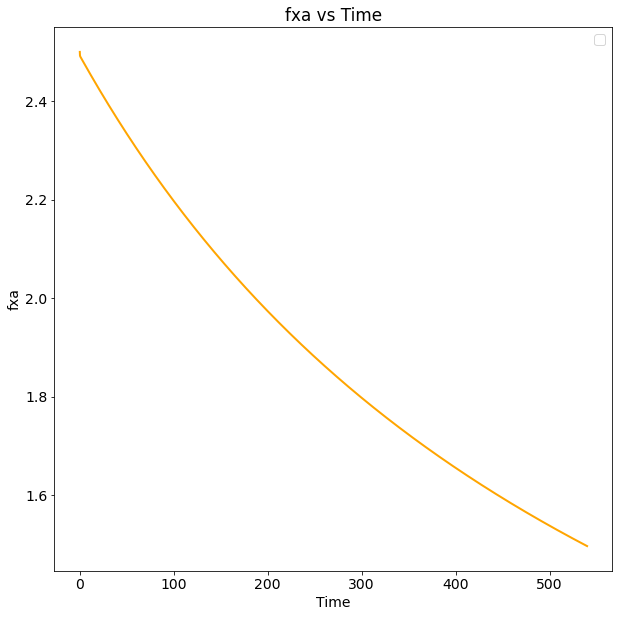

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


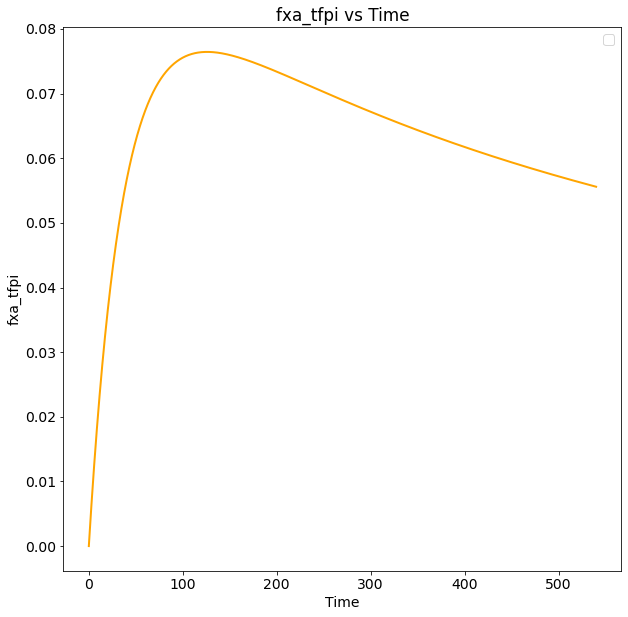

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


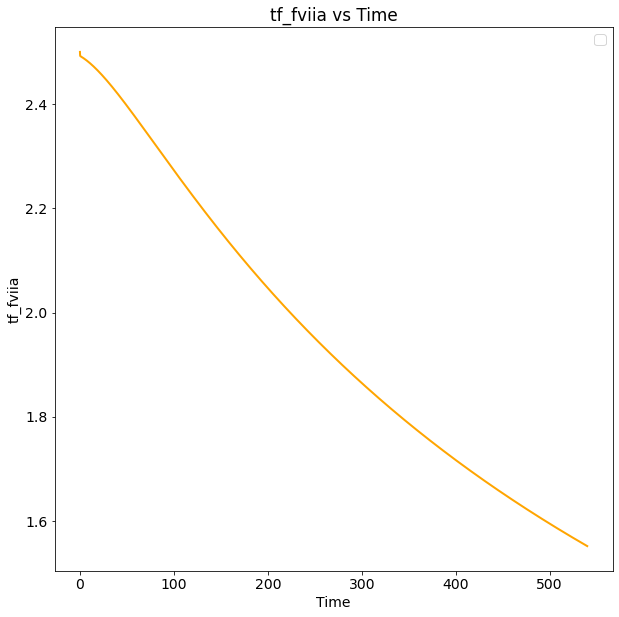

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


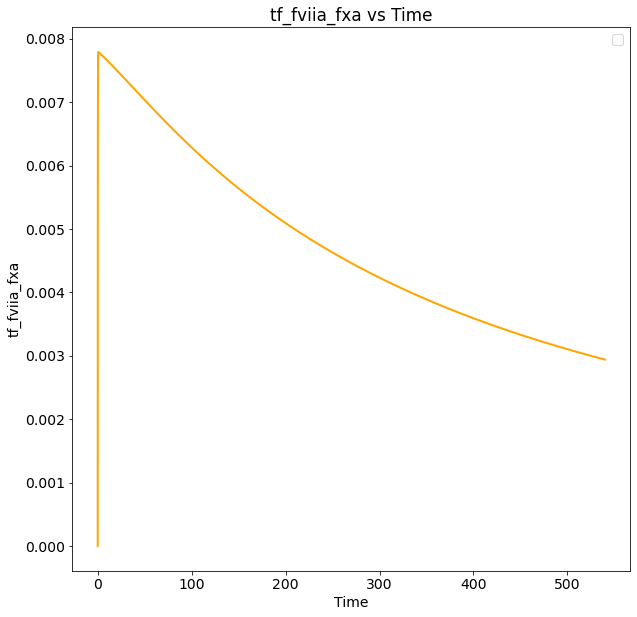

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


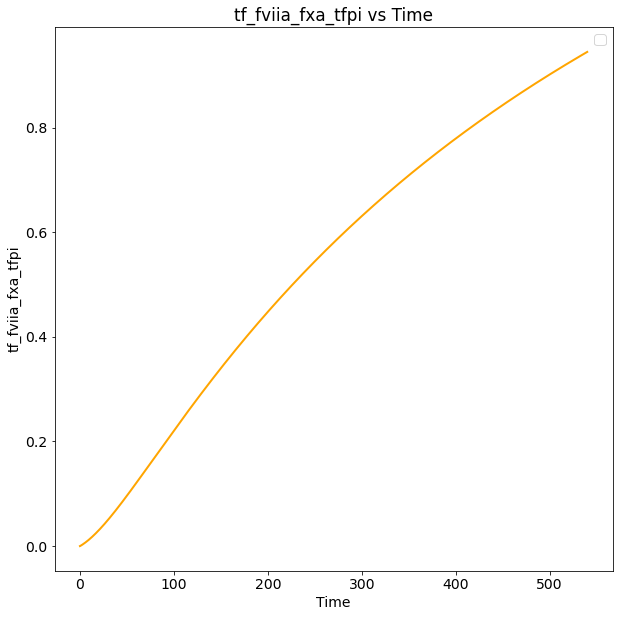

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


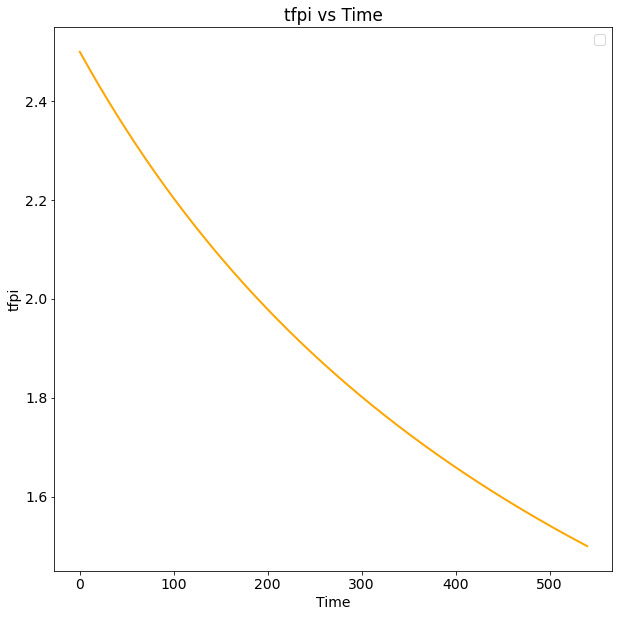

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import os


# Load and read in all lines the file
namef = saveLocation+nameFromTextFile+'.raw'
filename = namef  # <-- Replace with your actual file
with open(filename, 'r') as f:
    lines = f.readlines()
#     print(lines)

# Example raw_data creation (modify this part according to how you are appending to raw_data)
# raw_data = []

# Assuming you append rows to raw_data here, make sure each row is the same length:
# Example:
# raw_data.append([time_value, some_value, another_value])
# raw_data.append([time_value2, some_value2, another_value2])

# Convert raw_data to a NumPy array only if it is consistently structured
# try:
#     data = np.array(raw_data, dtype=object)
#     print(f"Data shape: {data.shape}")  # Debugging step to check the shape

#     # Ensure there are at least 2 dimensions and the array has data
#     if data.ndim == 2 and data.shape[1] > 0:
#         time = data[:, 0]
#         print(time)  # Process your time data
#     else:
#         print("Error: The raw data does not have the expected 2D shape.")
# except Exception as e:
#     print(f"Error during data conversion: {e}")

# Find where variable information and data information begin
variables = []
# data_start = 0
# var_start = 0
for i, line in enumerate(lines):
    if line.strip().startswith("Variables:"):
        var_start = i + 1
    elif line.strip().startswith("Values:"):
        data_start = i + 1
    elif line.strip().startswith("No. Variables:"):
        totVariables = int(line.split(":")[1].strip()) #get variable count for parsing from data file
        
        
print(data_start, var_start, totVariables)

# Get variables from top portion  under "Variables" for count specified in raw data file
for line in lines[var_start:var_start+totVariables]:
    parts = line.strip().split()
#     print("Parts in line:", parts)

    if len(parts) == 3:
        count, name, units = parts
        
        if name.startswith("v(") and name.endswith(")"):
            name = name[2:-1]  # strip the "v(" and ")"
            variables.append(name)
        else:
            variables.append(name)


# print(variables, len(variables))

# Get data into one container
raw_data = []
current_row = []
for line in lines[data_start:]:
    line = line.strip()
    if not line:
        continue
    parts = line.split()
#     print(dataParts)
    if len(parts) == 1:
        if current_row:
            raw_data.append(current_row)
        current_row = [float(parts[0])]
    else:
        if len(parts) == 2:
            if current_row:
                raw_data.append(current_row)
#             print(parts)
            current_row = [float(parts[1])]

if current_row:
    raw_data.append(current_row)
# print(raw_data)
# take data and assign it to the corresponding variables dividing into every 7th data point
data_dict = {}
for i, var_name in enumerate(variables):
    data_dict[var_name] = raw_data[i::len(variables)]
# print(data_dict)
time = data_dict['time']  # assgn time varriable for plotting


# Saving info
saveLocation = str("C:/Users/gvrqtpi/Desktop/research/plots")

plt.rcParams.update({'font.size': 14})



# Plot for each variable
for var_name, values in list(data_dict.items())[1:]:
    # Create the plot
    fig, ax = plt.subplots(figsize = (10, 10))
#     fig.add_subplot(111)
    
#     plt.scatter(time, values, label=var_name, linewidth = 2, color='orange', s=17, alpha=0.7)
    plt.plot(time, values, color='orange', linewidth=2)
#     plt.add_subplot(111)
    ax.set_xlabel("Time")
    ax.set_ylabel(var_name)
    ax.set_title(f"{var_name} vs Time")
#     ax.tight_layout()
    ax.legend(loc='best')
    plt.show()

    # Display grid
    ax.grid(False)

    plt.savefig(os.path.join(saveLocation, f"{var_name}_vs_time.png"), dpi = 300)
    plt.close()
  


In [26]:
# import matplotlib.pyplot as plt
# import numpy as np
# import os

# def process_file(filename, save_location, variables, data_dict, time_index=0):
#     with open(filename, 'r') as f:
#         lines = f.readlines()

#     data_start = 0
#     var_start = 0
#     totVariables = 0
#     for i, line in enumerate(lines):
#         if line.strip().startswith("Variables:"):
#             var_start = i + 1
#         elif line.strip().startswith("Values:"):
#             data_start = i + 1
#         elif line.strip().startswith("No. Variables:"):
#             totVariables = int(line.split(":")[1].strip())

#     # Extract variables from the "Variables" section
#     for line in lines[var_start:var_start + totVariables]:
#         parts = line.strip().split()
#         if len(parts) == 3:
#             count, name, units = parts
#             if name.startswith("v(") and name.endswith(")"):
#                 name = name[2:-1]  # strip the "v(" and ")"
#             variables.append(name)

#     # Extract data from the "Values" section
#     raw_data = []
#     current_row = []
#     for line in lines[data_start:]:
#         line = line.strip()
#         if not line:
#             continue
#         parts = line.split()
#         if len(parts) == 1:
#             if current_row:
#                 raw_data.append(current_row)
#             current_row = [float(parts[0])]
#         else:
#             if len(parts) == 2:
#                 if current_row:
#                     raw_data.append(current_row)
#                 current_row = [float(parts[1])]

#     if current_row:
#         raw_data.append(current_row)

#     # Populate the data_dict with variables and data
#     for i, var_name in enumerate(variables):
#         if var_name not in data_dict:
#             data_dict[var_name] = []
#         data_dict[var_name].append(raw_data[i::len(variables)])

#     # Return the time data for plotting
#     time = data_dict.get('time', [])[time_index] if 'time' in data_dict else []
#     return time

# def process_multiple_files(file_paths, save_location):
#     variables = []
#     data_dict = {}
    
#     # Process each file and collect data
#     for filename in file_paths:
#         time = process_file(filename, save_location, variables, data_dict)
    
#     # Plot each variable from all files on the same graph
#     for var_name, data_list in data_dict.items():
#         if var_name != 'time':  # Skip 'time' variable, as it's common across files
#             plt.figure(figsize=(10, 10))
#             for i, data in enumerate(data_list):
#                 label = f"File {i+1}"  # Label for each file's data
#                 plt.plot(time, data, label=label, linewidth=2)

#             plt.xlabel("Time")
#             plt.ylabel(var_name)
#             plt.title(f"{var_name} vs Time")
#             plt.legend(loc='best')
#             plt.grid(True)

#             # Save the plot with a unique name
#             plot_filename = f"{os.path.splitext(os.path.basename(file_paths[0]))[0]}_{var_name}_vs_time.png"
#             plt.savefig(os.path.join(save_location, plot_filename), dpi=300)
#             plt.close()

# # Example usage:#     "C:\Users\gvrqtpi\Desktop\research\parsLoop1.txt.raw"

# file_paths = [
#     "C:/Users/gvrqtpi/Desktop/research/parsLoop1.txt.raw",
# #     "C:/Users/gvrqtpi/Desktop/research/plotsparsLoop1.txt.raw",  # Add your file paths here

#     "C:/Users/gvrqtpi/Desktop/research/parsLoop1TRY.txt.raw"
#     ]

# save_location = "C:/Users/gvrqtpi/Desktop/research/plots"  # Specify your save location
# process_multiple_files(file_paths, save_location)


In [27]:
 def get_safe_label_position(time, value, offset_x, offset_y, axis_limits):
    lower_lim, upper_lim = axis_limits
    # Check if the label will go off the axis limits
    if time + offset_x > upper_lim or value + offset_y > upper_lim:
        return time - offset_x, value - offset_y  # Move label left/down
    elif time + offset_x < lower_lim or value + offset_y < lower_lim:
        return time + offset_x, value + offset_y  # Move label right/up
    else:
        return time + offset_x, value + offset_y  # Default offset


In [28]:
 # Ensure label doesn't go off-screen
def get_safe_label_position(time, value, offset_x, offset_y, axis_limits):
    lower_lim, upper_lim = axis_limits
    if time + offset_x > max(time) or value + offset_y > upper_lim:
        return time - offset_x, value - offset_y
    elif time + offset_x < lower_lim or value + offset_y < lower_lim:
        return time + offset_x, value + offset_y
    else:
        return time + offset_x, value + offset_y

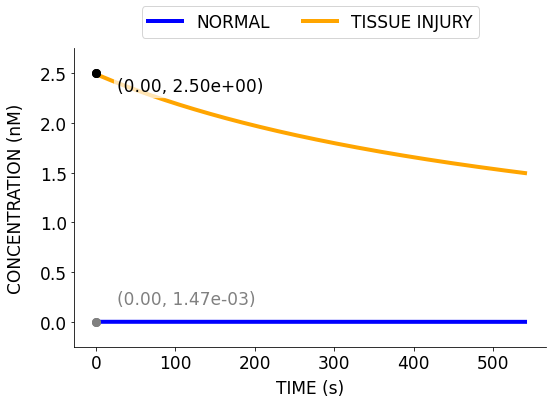

 Saved comparison plot for fxa


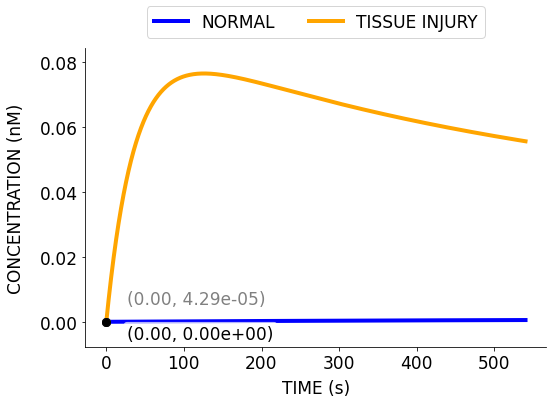

 Saved comparison plot for fxa_tfpi


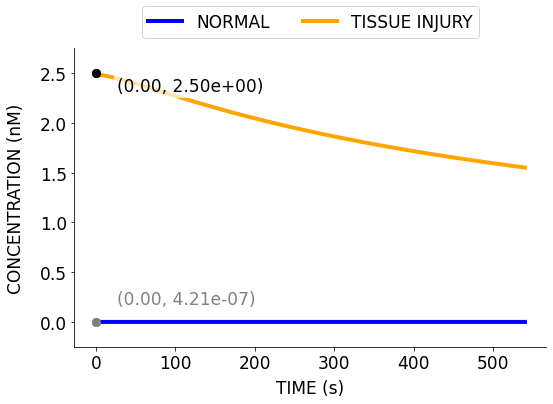

 Saved comparison plot for tf_fviia


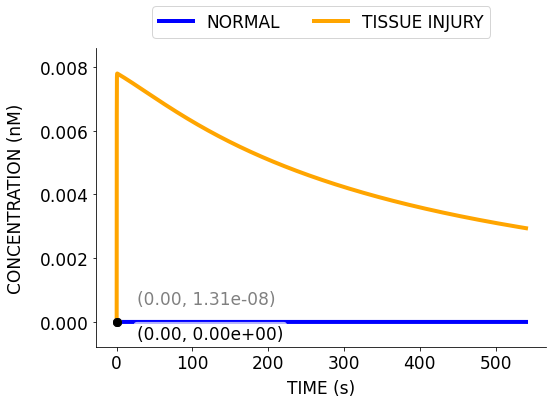

 Saved comparison plot for tf_fviia_fxa


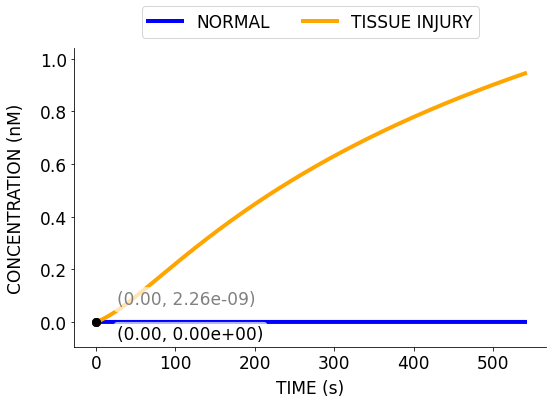

 Saved comparison plot for tf_fviia_fxa_tfpi


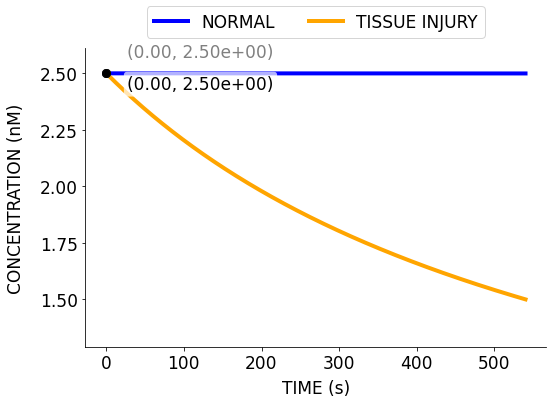

 Saved comparison plot for tfpi


In [35]:
import matplotlib.pyplot as plt
import math
import numpy as np
import os

def parse_raw_file(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()

    # Initialize variables
    var_start = data_start = totVariables = None
    variables = []

    # Locate section headers
    for i, line in enumerate(lines):
        if line.strip().startswith("Variables:"):
            var_start = i + 1
        elif line.strip().startswith("Values:"):
            data_start = i + 1
        elif line.strip().startswith("No. Variables:"):
            totVariables = int(line.split(":")[1].strip())

    if None in (var_start, data_start, totVariables):
        raise ValueError(f"Could not parse required sections in {filepath}")

    # Extract variable names
    for line in lines[var_start:var_start + totVariables]:
        parts = line.strip().split()
        if len(parts) == 3:
            _, name, _ = parts
            if name.startswith("v(") and name.endswith(")"):
                name = name[2:-1]
            variables.append(name)

    # Extract numerical data
    raw_data = []
    current_row = []
    for line in lines[data_start:]:
        parts = line.strip().split()
        if not parts:
            continue
        if len(parts) == 1:
            if current_row:
                raw_data.append(current_row)
            current_row = [float(parts[0])]
        elif len(parts) == 2:
            if current_row:
                raw_data.append(current_row)
            current_row = [float(parts[1])]

    if current_row:
        raw_data.append(current_row)

    # Organize data into a dictionary by variable
    data_dict = {}
    for i, var_name in enumerate(variables):
        data_dict[var_name] = [row[0] for row in raw_data[i::len(variables)]]

    return data_dict

# ---------- CONFIG ----------
saveLocation = "C:/Users/gvrqtpi/Desktop/research/"
file1 = os.path.join(saveLocation, "plots/Loop1/verif/archive/iPadtestAutoBase.raw")  # ← file names to compare
file2 = os.path.join(saveLocation, "plots/Loop1/verif/rerun/parsLoop1.txt.raw" ) # ← file names to compare

# ---------- PROCESS ----------
data1 = parse_raw_file(file1)
data2 = parse_raw_file(file2)

time1 = data1["time"]
time2 = data2["time"]

# Plotting
plt.rcParams.update({'font.size': 17})

shared_vars = [v for v in data1 if v in data2 and v != "time"]

# Create the plot
# plt.plot(x, y, marker='o')  # Plot the line with markers

# Annotate the first point
# plt.annotate(f'({x[0]}, {y[0]})',  # Text of the annotation
#              xy=(x[0], y[0]),     # Coordinates of the point to annotate
#              xytext=(x[0] + 0.5, y[0] + 0.5), # Position of the text (offset from the point)
#              arrowprops=dict(facecolor='black', shrink=0.05))  # Arrow style


for var in shared_vars:
    fig, ax = plt.subplots(figsize=(8, 6))

#     ax.plot(time1, data1[var], label=f"{var} Normal", color='gray', linewidth=2)
#     ax.plot(time2, data2[var], label=f"{var} Tissue Injury", color='black', linestyle='--', linewidth=2)
#     ax.plot(time1, data1[var], marker = 'o', label=f"NORMAL", color='gray', linewidth=2)
    ax.plot(time1, data1[var], label=f"NORMAL", color='blue', linewidth=4)

#     plt.annotate(f'({time1[0]}, {data1[0]})',  # Text of the annotation
#              xy=(time1[0], data1[0]),     # Coordinates of the point to annotate
#              xytext=(time1[0] + 0.5, data1[0] + 0.5), # Position of the text (offset from the point)
#              arrowprops=dict(facecolor='black', shrink=0.05))  # Arrow style
#     ax.plot(time2, data2[var], marker = 'o', label=f"TISSUE INJURY", color='black')#, linewidth=2) #, linestyle='--')
    ax.plot(time2, data2[var], label=f"TISSUE INJURY", color='orange', linewidth=4) #, linestyle='--')

      # Add markers for the first point of each line
    ax.plot(time1[0], data1[var][0], marker='o', color='gray', markersize=8, zorder=5)
    ax.plot(time2[0], data2[var][0], marker='o', color='black', markersize=8, zorder=5)

#     # Add labels near the first point
#     ax.text(time1[0], data1[var][0], f"{time1[0], data1[var][0]}", color='gray', 
#             verticalalignment='top', horizontalalignment='left')
#     ax.text(time2[0], data2[var][0], f"{time2[0], data2[var][0]}", color='black', 
#             verticalalignment='top', horizontalalignment='left')



# Compute dynamic offsets based on data range
    x_range = max(time1) - min(time1)
    y_range = max(data1[var] + data2[var]) - min(data1[var] + data2[var])
    x_offset = x_range * 0.05  # 1% of x range
    y_offset = y_range * 0.07  # 1% of y range

    
    # Add first point markers
    ax.plot(time1[0], data1[var][0], marker='o', color='gray', markersize=8, zorder=5)
    ax.plot(time2[0], data2[var][0], marker='o', color='black', markersize=8, zorder=5)

    # Add labels near the first point with small relative offsets
    ax.text(time1[0] + x_offset, data1[var][0] + y_offset, f"({time1[0]:.2f}, {data1[var][0]:.2e})", color='gray',
            bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.2', alpha=0.7))

    ax.text(time2[0] + x_offset, data2[var][0] - y_offset, f"({time2[0]:.2f}, {data2[var][0]:.2e})", color='black',
            bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.2', alpha=0.7))
# Define the offset values
#    offset_x = 0.05  # Small horizontal offset to the right
#    offset_y = 0.05  # Small vertical offset upwards
#     # Ensure that the label does not overlap or go out of bounds
#     if time1[0] + offset_x < max(time1) and data1[var][0] + offset_y < max(data1[var]):
#         ax.text(time1[0] + offset_x, data1[var][0] + offset_y, f"({time1[0]}, {data1[var][0]})", color='gray',
#                 bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.5', alpha=0.7),
#                 fontsize=10, fontweight='bold')
#     else:
#         # If the offset goes out of bounds, adjust placement towards the bottom or left
#         ax.text(time1[0] - offset_x, data1[var][0] - offset_y, f"({time1[0]}, {data1[var][0]})", color='gray',
#                 bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.5', alpha=0.7),
#                 fontsize=10, fontweight='bold')

#     if time2[0] + offset_x < max(time2) and data2[var][0] + offset_y < max(data2[var]):
#         ax.text(time2[0] + offset_x, data2[var][0] + offset_y, f"({time2[0]}, {data2[var][0]})", color='black',
#                 bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.5', alpha=0.7),
#                 fontsize=10, fontweight='bold')
#     else:
#         # If the offset goes out of bounds, adjust placement towards the bottom or left
#         ax.text(time2[0] - offset_x, data2[var][0] - offset_y, f"({time2[0]}, {data2[var][0]})", color='black',
#                 bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.5', alpha=0.7),
#                 fontsize=10, fontweight='bold')


    # Add labels near the first point with offsets to prevent overlap
#     ax.text(time1[0] + 0.01, data1[var][0] + 0.01, f"({time1[0]}, {data1[var][0]})", color='gray', bbox=dict(facecolor='white', edgecolor='none', boxstyle='round', pad=27, alpha = 0.3))
#     ax.text(1, 1, 'boxed italics text in data coords', style='italic',
#         bbox={'facecolor': 'red', 'alpha': 0.5, 'pad': 10})
#     ax.text(time2[0], data2[var][0], f"({time2[0]}, {data2[var][0]})", color='black', 
#             verticalalignment='bottom', horizontalalignment='right',
#             fontsize=10, fontweight='bold', 
#             horizontalalignment='left', verticalalignment='top',
#             bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.5'))


    ax.set_xlabel("TIME (s)", labelpad = 7)#, fontsize = 17)
    ax.set_ylabel("CONCENTRATION (nM)", labelpad = 15)#, fontsize = 17)
#     Makes sure there isnt too many y axis ticks
    plt.locator_params(axis='y', nbins=6, prune=None)
    
    all_values = data1[var] + data2[var]
    min_val = min(all_values)
    max_val = max(all_values)
    range_val = max_val - min_val
#     buffer = range_val * 0.05 if range_val != 0 else 0.01
#     ax.set_ylim(min_val - buffer, max_val + buffer)

    # Handle the case of small range, values are very close to each other)
    if range_val == 0:
        buffer = abs(min_val * 0.01) if min_val != 0 else 0.1
        lower_lim = min_val - buffer
        upper_lim = max_val + buffer
    else:
        # Dynamically calculate the appropriate tick step
        if min_val > 0:
            magnitude = 10 ** math.floor(math.log10(range_val))
            tick_step = magnitude / 10  # You can adjust this factor (e.g., 5) for different granularity
        else:
            #  gives a buffer for better visualization of data around zero
            tick_step = 0.001  # manually adjust based on smallest values (e.g., 0.001, 0.01, etc.)

        lower_lim = math.floor(min_val / tick_step) * tick_step
        upper_lim = math.ceil(max_val / tick_step) * tick_step

        # Adds small buffer around the limits to not cut off part of the lines
        buffer = (upper_lim - lower_lim) * 0.1
        lower_lim -= buffer
        upper_lim += buffer

    ax.set_ylim(lower_lim, upper_lim)
    
        # Add buffer around axis limits to avoid clipping
    if range_val == 0:
        buffer = abs(min_val * 0.02) if min_val != 0 else 0.01
        lower_lim = min_val - buffer
        upper_lim = max_val + buffer
    else:
        # Dynamically calculate the appropriate tick step
        if min_val > 0:
            magnitude = 10 ** math.floor(math.log10(range_val))
            tick_step = magnitude / 10  # Adjust this factor for different granularity
        else:
            # Handle values around zero, giving a buffer for better visualization
            tick_step = 0.0001  # Adjust based on your dataset (e.g., 0.001, 0.01, etc.)

        lower_lim = math.floor(min_val / tick_step) * tick_step
        upper_lim = math.ceil(max_val / tick_step) * tick_step

        # Add small buffer around limits to ensure lines don't get clipped
        buffer = (upper_lim - lower_lim) * 0.1  # Adjust this buffer size if needed
        lower_lim -= buffer
        upper_lim += buffer

    ax.set_ylim(lower_lim, upper_lim)
    
    #     ax.set_title(f"{var} vs Time (Comparison)")
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.17), ncol = 2)
    ax.grid(False)
    # Hide the top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
#     plt.show()
    plt.savefig(os.path.join(saveLocation, f"{var}_comparison.png"), dpi=300)
    plt.close()

    print(f" Saved comparison plot for {var}")

    
    
    
    

    
    

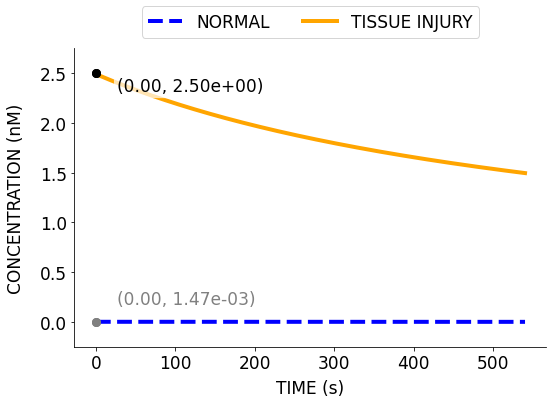

 Saved comparison plot for fxa


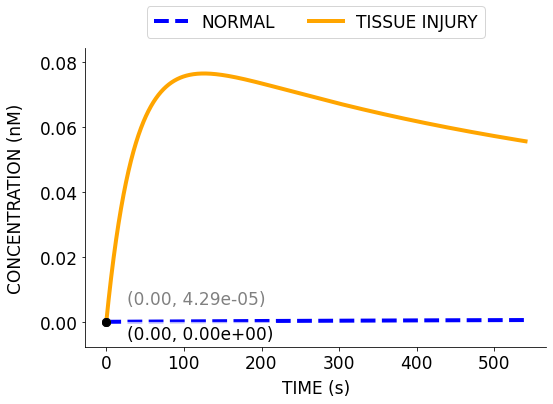

 Saved comparison plot for fxa_tfpi


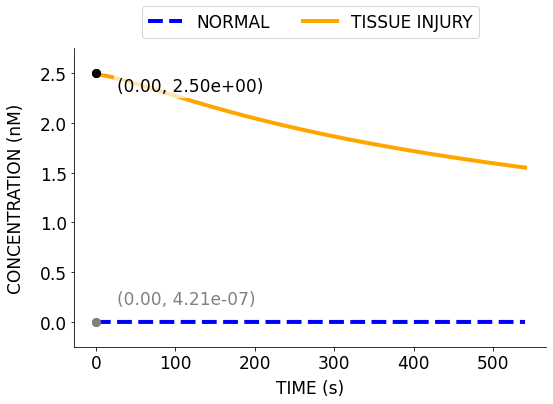

 Saved comparison plot for tf_fviia


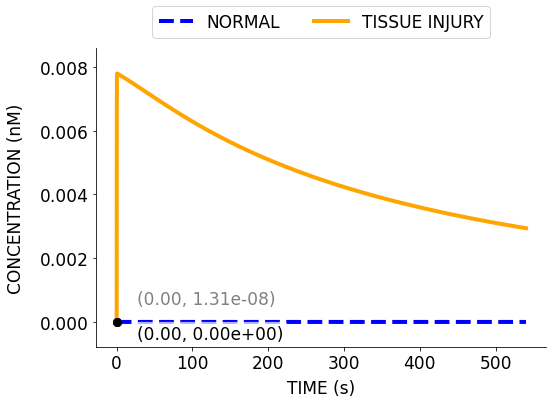

 Saved comparison plot for tf_fviia_fxa


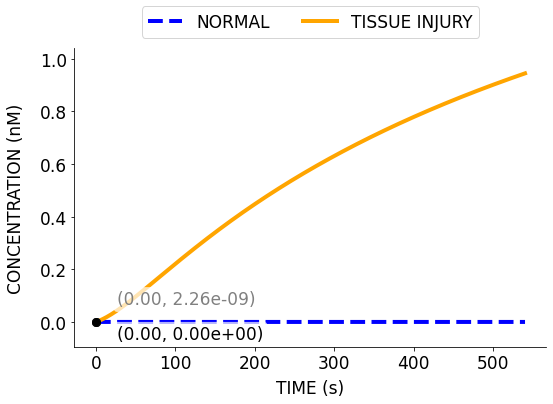

 Saved comparison plot for tf_fviia_fxa_tfpi


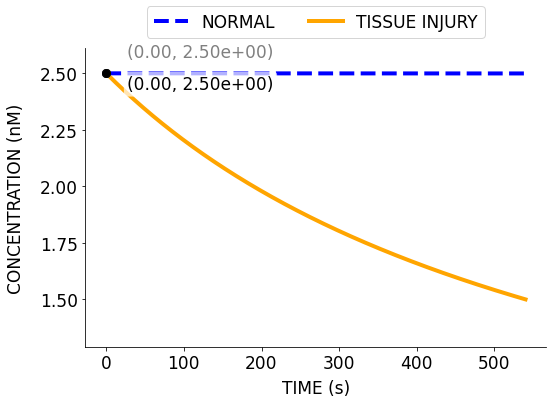

 Saved comparison plot for tfpi


In [30]:
import matplotlib.pyplot as plt
import math
import numpy as np
import os

def parse_raw_file(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()

    # Initialize variables
    var_start = data_start = totVariables = None
    variables = []

    # Locate section headers
    for i, line in enumerate(lines):
        if line.strip().startswith("Variables:"):
            var_start = i + 1
        elif line.strip().startswith("Values:"):
            data_start = i + 1
        elif line.strip().startswith("No. Variables:"):
            totVariables = int(line.split(":")[1].strip())

    if None in (var_start, data_start, totVariables):
        raise ValueError(f"Could not parse required sections in {filepath}")

    # Extract variable names
    for line in lines[var_start:var_start + totVariables]:
        parts = line.strip().split()
        if len(parts) == 3:
            _, name, _ = parts
            if name.startswith("v(") and name.endswith(")"):
                name = name[2:-1]
            variables.append(name)

    # Extract numerical data
    raw_data = []
    current_row = []
    for line in lines[data_start:]:
        parts = line.strip().split()
        if not parts:
            continue
        if len(parts) == 1:
            if current_row:
                raw_data.append(current_row)
            current_row = [float(parts[0])]
        elif len(parts) == 2:
            if current_row:
                raw_data.append(current_row)
            current_row = [float(parts[1])]

    if current_row:
        raw_data.append(current_row)

    # Organize data into a dictionary by variable
    data_dict = {}
    for i, var_name in enumerate(variables):
        data_dict[var_name] = [row[0] for row in raw_data[i::len(variables)]]

    return data_dict

# ---------- CONFIG ----------
saveLocation = "C:/Users/gvrqtpi/Desktop/research/"
file1 = os.path.join(saveLocation, "plots/Loop1/verif/archive/iPadtestAutoBase.raw")  # ← file names to compare
file2 = os.path.join(saveLocation, "plots/Loop1/verif/rerun/parsLoop1.txt.raw" ) # ← file names to compare

# ---------- PROCESS ----------
data1 = parse_raw_file(file1)
data2 = parse_raw_file(file2)

time1 = data1["time"]
time2 = data2["time"]

# Plotting
plt.rcParams.update({'font.size': 17})

shared_vars = [v for v in data1 if v in data2 and v != "time"]

# Create the plot
# plt.plot(x, y, marker='o')  # Plot the line with markers

# Annotate the first point
# plt.annotate(f'({x[0]}, {y[0]})',  # Text of the annotation
#              xy=(x[0], y[0]),     # Coordinates of the point to annotate
#              xytext=(x[0] + 0.5, y[0] + 0.5), # Position of the text (offset from the point)
#              arrowprops=dict(facecolor='black', shrink=0.05))  # Arrow style


for var in shared_vars:
    fig, ax = plt.subplots(figsize=(8, 6))

#     ax.plot(time1, data1[var], label=f"{var} Normal", color='gray', linewidth=2)
#     ax.plot(time2, data2[var], label=f"{var} Tissue Injury", color='black', linestyle='--', linewidth=2)
#     ax.plot(time1, data1[var], marker = 'o', label=f"NORMAL", color='gray', linewidth=2)
    ax.plot(time1, data1[var], label=f"NORMAL", linestyle='--', color='blue', linewidth=4)

#     plt.annotate(f'({time1[0]}, {data1[0]})',  # Text of the annotation
#              xy=(time1[0], data1[0]),     # Coordinates of the point to annotate
#              xytext=(time1[0] + 0.5, data1[0] + 0.5), # Position of the text (offset from the point)
#              arrowprops=dict(facecolor='black', shrink=0.05))  # Arrow style
#     ax.plot(time2, data2[var], marker = 'o', label=f"TISSUE INJURY", color='black')#, linewidth=2) #, linestyle='--')
    ax.plot(time2, data2[var], label=f"TISSUE INJURY", color='orange', linewidth=4) #, linestyle='--')

      # Add markers for the first point of each line
    ax.plot(time1[0], data1[var][0], marker='o', color='gray', markersize=8, zorder=5)
    ax.plot(time2[0], data2[var][0], marker='o', color='black', markersize=8, zorder=5)

#     # Add labels near the first point
#     ax.text(time1[0], data1[var][0], f"{time1[0], data1[var][0]}", color='gray', 
#             verticalalignment='top', horizontalalignment='left')
#     ax.text(time2[0], data2[var][0], f"{time2[0], data2[var][0]}", color='black', 
#             verticalalignment='top', horizontalalignment='left')



# Compute dynamic offsets based on data range
    x_range = max(time1) - min(time1)
    y_range = max(data1[var] + data2[var]) - min(data1[var] + data2[var])
    x_offset = x_range * 0.05  # 1% of x range
    y_offset = y_range * 0.07  # 1% of y range

    
    # Add first point markers
    ax.plot(time1[0], data1[var][0], marker='o', color='gray', markersize=8, zorder=5)
    ax.plot(time2[0], data2[var][0], marker='o', color='black', markersize=8, zorder=5)

    # Add labels near the first point with small relative offsets
    ax.text(time1[0] + x_offset, data1[var][0] + y_offset, f"({time1[0]:.2f}, {data1[var][0]:.2e})", color='gray',
            bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.2', alpha=0.7))

    ax.text(time2[0] + x_offset, data2[var][0] - y_offset, f"({time2[0]:.2f}, {data2[var][0]:.2e})", color='black',
            bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.2', alpha=0.7))
# Define the offset values
#    offset_x = 0.05  # Small horizontal offset to the right
#    offset_y = 0.05  # Small vertical offset upwards
#     # Ensure that the label does not overlap or go out of bounds
#     if time1[0] + offset_x < max(time1) and data1[var][0] + offset_y < max(data1[var]):
#         ax.text(time1[0] + offset_x, data1[var][0] + offset_y, f"({time1[0]}, {data1[var][0]})", color='gray',
#                 bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.5', alpha=0.7),
#                 fontsize=10, fontweight='bold')
#     else:
#         # If the offset goes out of bounds, adjust placement towards the bottom or left
#         ax.text(time1[0] - offset_x, data1[var][0] - offset_y, f"({time1[0]}, {data1[var][0]})", color='gray',
#                 bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.5', alpha=0.7),
#                 fontsize=10, fontweight='bold')

#     if time2[0] + offset_x < max(time2) and data2[var][0] + offset_y < max(data2[var]):
#         ax.text(time2[0] + offset_x, data2[var][0] + offset_y, f"({time2[0]}, {data2[var][0]})", color='black',
#                 bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.5', alpha=0.7),
#                 fontsize=10, fontweight='bold')
#     else:
#         # If the offset goes out of bounds, adjust placement towards the bottom or left
#         ax.text(time2[0] - offset_x, data2[var][0] - offset_y, f"({time2[0]}, {data2[var][0]})", color='black',
#                 bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.5', alpha=0.7),
#                 fontsize=10, fontweight='bold')


    # Add labels near the first point with offsets to prevent overlap
#     ax.text(time1[0] + 0.01, data1[var][0] + 0.01, f"({time1[0]}, {data1[var][0]})", color='gray', bbox=dict(facecolor='white', edgecolor='none', boxstyle='round', pad=27, alpha = 0.3))
#     ax.text(1, 1, 'boxed italics text in data coords', style='italic',
#         bbox={'facecolor': 'red', 'alpha': 0.5, 'pad': 10})
#     ax.text(time2[0], data2[var][0], f"({time2[0]}, {data2[var][0]})", color='black', 
#             verticalalignment='bottom', horizontalalignment='right',
#             fontsize=10, fontweight='bold', 
#             horizontalalignment='left', verticalalignment='top',
#             bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.5'))


    ax.set_xlabel("TIME (s)", labelpad = 7)#, fontsize = 17)
    ax.set_ylabel("CONCENTRATION (nM)", labelpad = 15)#, fontsize = 17)
#     Makes sure there isnt too many y axis ticks
    plt.locator_params(axis='y', nbins=6, prune=None)
    
    all_values = data1[var] + data2[var]
    min_val = min(all_values)
    max_val = max(all_values)
    range_val = max_val - min_val
#     buffer = range_val * 0.05 if range_val != 0 else 0.01
#     ax.set_ylim(min_val - buffer, max_val + buffer)

    # Handle the case of small range, values are very close to each other)
    if range_val == 0:
        buffer = abs(min_val * 0.01) if min_val != 0 else 0.1
        lower_lim = min_val - buffer
        upper_lim = max_val + buffer
    else:
        # Dynamically calculate the appropriate tick step
        if min_val > 0:
            magnitude = 10 ** math.floor(math.log10(range_val))
            tick_step = magnitude / 10  # You can adjust this factor (e.g., 5) for different granularity
        else:
            #  gives a buffer for better visualization of data around zero
            tick_step = 0.001  # manually adjust based on smallest values (e.g., 0.001, 0.01, etc.)

        lower_lim = math.floor(min_val / tick_step) * tick_step
        upper_lim = math.ceil(max_val / tick_step) * tick_step

        # Adds small buffer around the limits to not cut off part of the lines
        buffer = (upper_lim - lower_lim) * 0.1
        lower_lim -= buffer
        upper_lim += buffer

    ax.set_ylim(lower_lim, upper_lim)
    
        # Add buffer around axis limits to avoid clipping
    if range_val == 0:
        buffer = abs(min_val * 0.02) if min_val != 0 else 0.01
        lower_lim = min_val - buffer
        upper_lim = max_val + buffer
    else:
        # Dynamically calculate the appropriate tick step
        if min_val > 0:
            magnitude = 10 ** math.floor(math.log10(range_val))
            tick_step = magnitude / 10  # Adjust this factor for different granularity
        else:
            # Handle values around zero, giving a buffer for better visualization
            tick_step = 0.0001  # Adjust based on your dataset (e.g., 0.001, 0.01, etc.)

        lower_lim = math.floor(min_val / tick_step) * tick_step
        upper_lim = math.ceil(max_val / tick_step) * tick_step

        # Add small buffer around limits to ensure lines don't get clipped
        buffer = (upper_lim - lower_lim) * 0.1  # Adjust this buffer size if needed
        lower_lim -= buffer
        upper_lim += buffer

    ax.set_ylim(lower_lim, upper_lim)
    
    #     ax.set_title(f"{var} vs Time (Comparison)")
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.17), ncol = 2)
    ax.grid(False)
    # Hide the top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()

    plt.savefig(os.path.join(saveLocation, f"{var}_comparison.png"), dpi=300)
    plt.show()
    plt.close(fig)

    print(f" Saved comparison plot for {var}")

    
    
    
    

    
    

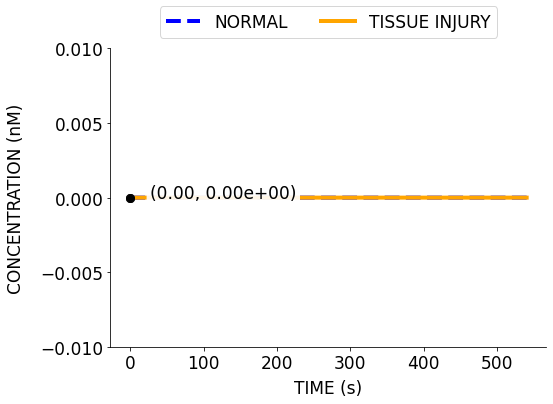

 Saved comparison plot for ca


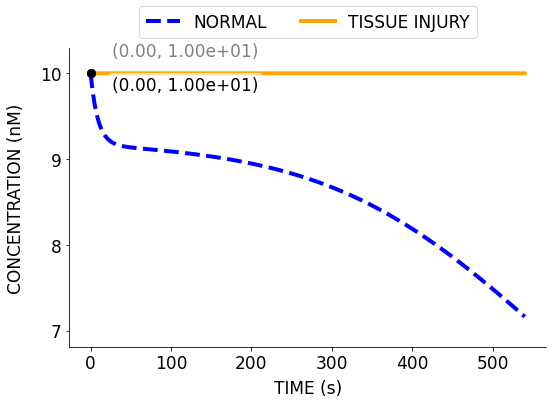

 Saved comparison plot for fvii


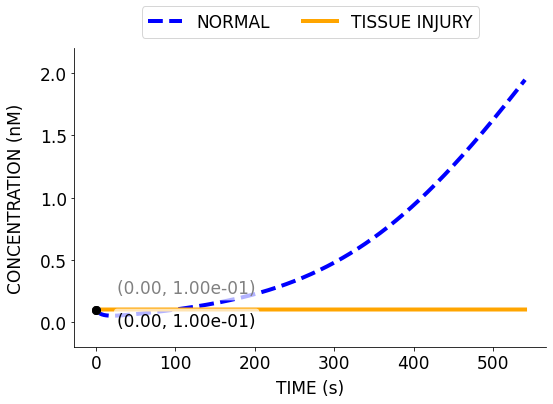

 Saved comparison plot for fviia


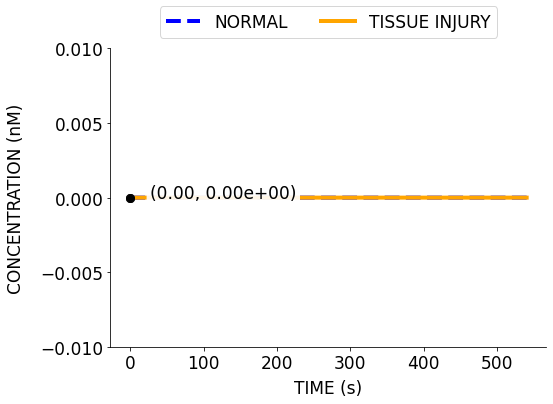

 Saved comparison plot for fviia_ca


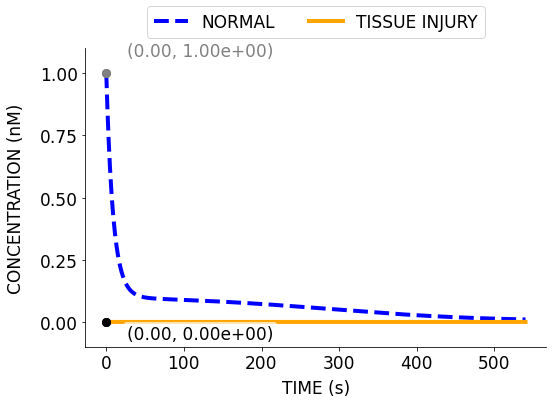

 Saved comparison plot for tf


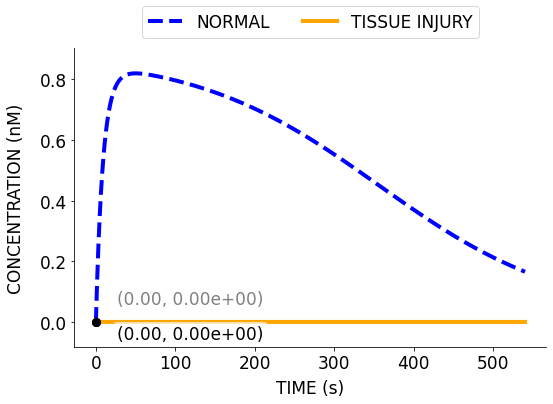

 Saved comparison plot for tf_fvii


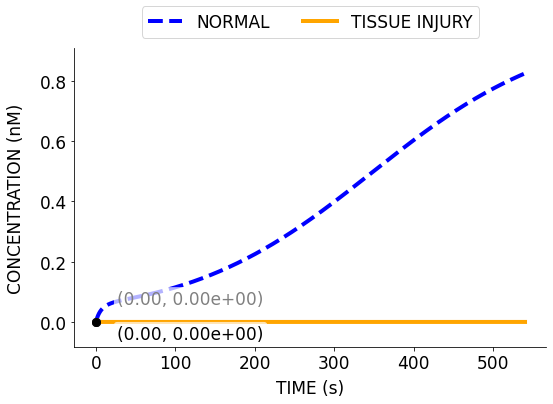

 Saved comparison plot for tf_fviia


In [31]:
import matplotlib.pyplot as plt
import math
import numpy as np
import os

def parse_raw_file(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()

    # Initialize variables
    var_start = data_start = totVariables = None
    variables = []

    # Locate section headers
    for i, line in enumerate(lines):
        if line.strip().startswith("Variables:"):
            var_start = i + 1
        elif line.strip().startswith("Values:"):
            data_start = i + 1
        elif line.strip().startswith("No. Variables:"):
            totVariables = int(line.split(":")[1].strip())

    if None in (var_start, data_start, totVariables):
        raise ValueError(f"Could not parse required sections in {filepath}")

    # Extract variable names
    for line in lines[var_start:var_start + totVariables]:
        parts = line.strip().split()
        if len(parts) == 3:
            _, name, _ = parts
            if name.startswith("v(") and name.endswith(")"):
                name = name[2:-1]
            variables.append(name)

    # Extract numerical data
    raw_data = []
    current_row = []
    for line in lines[data_start:]:
        parts = line.strip().split()
        if not parts:
            continue
        if len(parts) == 1:
            if current_row:
                raw_data.append(current_row)
            current_row = [float(parts[0])]
        elif len(parts) == 2:
            if current_row:
                raw_data.append(current_row)
            current_row = [float(parts[1])]

    if current_row:
        raw_data.append(current_row)

    # Organize data into a dictionary by variable
    data_dict = {}
    for i, var_name in enumerate(variables):
        data_dict[var_name] = [row[0] for row in raw_data[i::len(variables)]]

    return data_dict

# ---------- CONFIG ----------
saveLocation = "C:/Users/gvrqtpi/Desktop/research/"
file1 = os.path.join(saveLocation, "plotsparsExtrinsic.txt.raw") #"plots/Loop1/verif/archive/iPadtestAutoBase.raw")  # ← file names to compare
file2 = os.path.join(saveLocation, "plotsparsExtrinsicstable.txt.raw") #"plots/Loop1/verif/rerun/parsLoop1.txt.raw" ) # ← file names to compare

# ---------- PROCESS ----------
data1 = parse_raw_file(file1)
data2 = parse_raw_file(file2)

time1 = data1["time"]
time2 = data2["time"]

# Plotting
plt.rcParams.update({'font.size': 17})

shared_vars = [v for v in data1 if v in data2 and v != "time"]


for var in shared_vars:
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Set background to white for figure and axes 
    fig.patch.set_facecolor('white')  # Set the figure background to white
    ax.set_facecolor('white')  # Set the axes background to white
    
    ax.plot(time1, data1[var], label=f"NORMAL",linestyle='--', color='blue', linewidth=4)

    ax.plot(time2, data2[var], label=f"TISSUE INJURY", color='orange', linewidth=4) #, linestyle='--')

    # Add markers for the first point of each line
    ax.plot(time1[0], data1[var][0], marker='o', color='gray', markersize=8, zorder=5)
    ax.plot(time2[0], data2[var][0], marker='o', color='black', markersize=8, zorder=5)


    # Compute dynamic offsets based on data range
    x_range = max(time1) - min(time1)
    y_range = max(data1[var] + data2[var]) - min(data1[var] + data2[var])
    x_offset = x_range * 0.05  # 1% of x range
    y_offset = y_range * 0.07  # 1% of y range

    
    # Add first point markers
    ax.plot(time1[0], data1[var][0], marker='o', color='gray', markersize=8, zorder=5)
    ax.plot(time2[0], data2[var][0], marker='o', color='black', markersize=8, zorder=5)

    # Add labels near the first point with small relative offsets
    ax.text(time1[0] + x_offset, data1[var][0] + y_offset, f"({time1[0]:.2f}, {data1[var][0]:.2e})", color='gray',
            bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.2', alpha=0.7))

    ax.text(time2[0] + x_offset, data2[var][0] - y_offset, f"({time2[0]:.2f}, {data2[var][0]:.2e})", color='black',
            bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.2', alpha=0.7))


    ax.set_xlabel("TIME (s)", labelpad = 7)#, fontsize = 17)
    ax.set_ylabel("CONCENTRATION (nM)", labelpad = 15)#, fontsize = 17)
#     Makes sure there isnt too many y axis ticks
    plt.locator_params(axis='y', nbins=6, prune=None)
    
    all_values = data1[var] + data2[var]
    min_val = min(all_values)
    max_val = max(all_values)
    range_val = max_val - min_val
#     buffer = range_val * 0.05 if range_val != 0 else 0.01
#     ax.set_ylim(min_val - buffer, max_val + buffer)

    # Handle the case of small range, values are very close to each other)
    if range_val == 0:
        buffer = abs(min_val * 0.01) if min_val != 0 else 0.1
        lower_lim = min_val - buffer
        upper_lim = max_val + buffer
    else:
        # Dynamically calculate the appropriate tick step
        if min_val > 0:
            magnitude = 10 ** math.floor(math.log10(range_val))
            tick_step = magnitude / 10  # You can adjust this factor (e.g., 5) for different granularity
        else:
            #  gives a buffer for better visualization of data around zero
            tick_step = 0.001  # manually adjust based on smallest values (e.g., 0.001, 0.01, etc.)

        lower_lim = math.floor(min_val / tick_step) * tick_step
        upper_lim = math.ceil(max_val / tick_step) * tick_step

        # Adds small buffer around the limits to not cut off part of the lines
        buffer = (upper_lim - lower_lim) * 0.1
        lower_lim -= buffer
        upper_lim += buffer

    ax.set_ylim(lower_lim, upper_lim)
    
        # Add buffer around axis limits to avoid clipping
    if range_val == 0:
        buffer = abs(min_val * 0.02) if min_val != 0 else 0.01
        lower_lim = min_val - buffer
        upper_lim = max_val + buffer
    else:
        # Dynamically calculate the appropriate tick step
        if min_val > 0:
            magnitude = 10 ** math.floor(math.log10(range_val))
            tick_step = magnitude / 10  # Adjust this factor for different granularity
        else:
            # Handle values around zero, giving a buffer for better visualization
            tick_step = 0.0001  # Adjust based on your dataset (e.g., 0.001, 0.01, etc.)

        lower_lim = math.floor(min_val / tick_step) * tick_step
        upper_lim = math.ceil(max_val / tick_step) * tick_step

        # Add small buffer around limits to ensure lines don't get clipped
        buffer = (upper_lim - lower_lim) * 0.1  # Adjust this buffer size if needed
        lower_lim -= buffer
        upper_lim += buffer

    ax.set_ylim(lower_lim, upper_lim)
    
    #     ax.set_title(f"{var} vs Time (Comparison)")
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.17), ncol = 2)
    ax.grid(False)
    # Hide the top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()

    plt.savefig(os.path.join(saveLocation, f"{var}_comparison.svg"), facecolor='white', dpi=300, format='svg')
#     plt.savefig('my_graph.svg', format='svg')
    plt.show()
    plt.close(fig)

    print(f" Saved comparison plot for {var}")

    
    
    
    

    
    

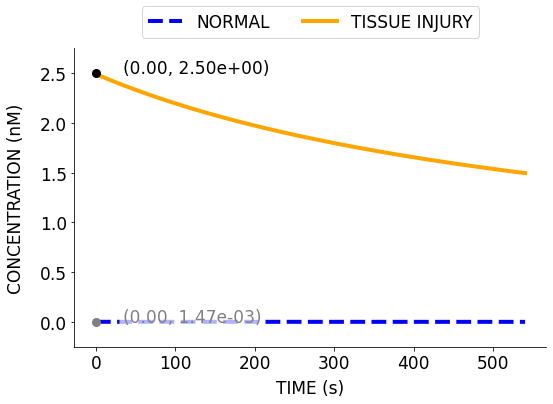

Saved comparison plot for fxa


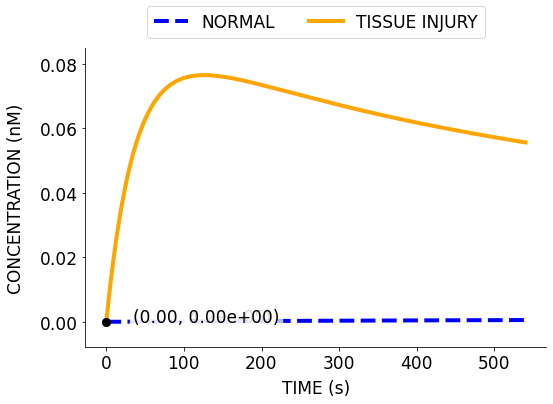

Saved comparison plot for fxa_tfpi


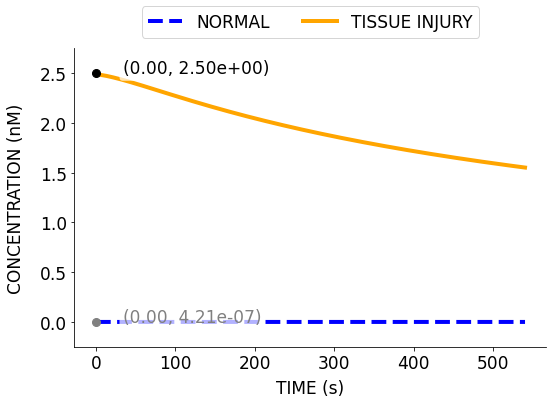

Saved comparison plot for tf_fviia


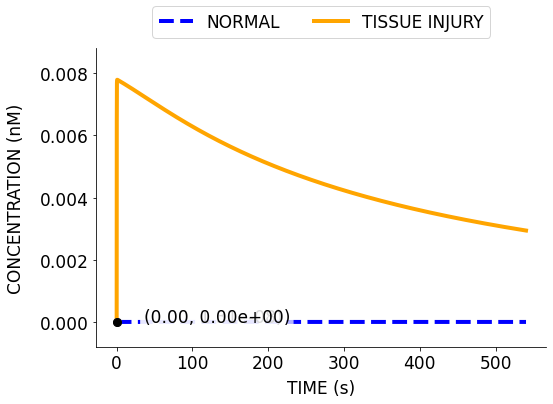

Saved comparison plot for tf_fviia_fxa


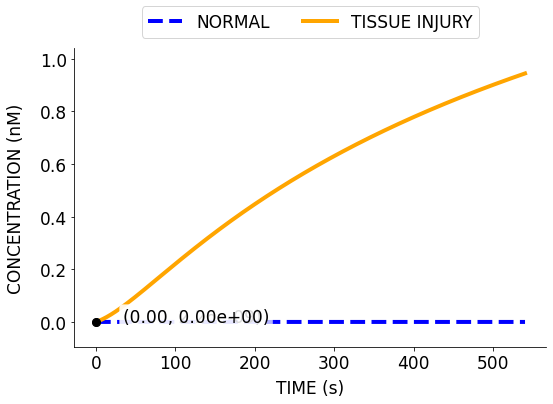

Saved comparison plot for tf_fviia_fxa_tfpi


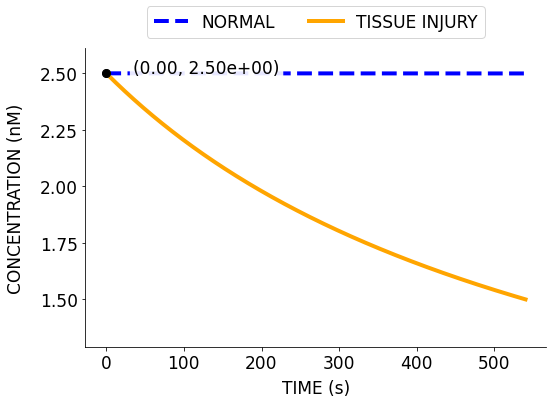

Saved comparison plot for tfpi


In [78]:
import matplotlib.pyplot as plt
import math
import numpy as np
import os

import matplotlib.pyplot as plt
import math
import numpy as np
import os

def parse_raw_file(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()

    # Initialize variables
    var_start = data_start = totVariables = None
    variables = []

    # Locate section headers
    for i, line in enumerate(lines):
        if line.strip().startswith("Variables:"):
            var_start = i + 1
        elif line.strip().startswith("Values:"):
            data_start = i + 1
        elif line.strip().startswith("No. Variables:"):
            totVariables = int(line.split(":")[1].strip())

    if None in (var_start, data_start, totVariables):
        raise ValueError(f"Could not parse required sections in {filepath}")

    # Extract variable names
    for line in lines[var_start:var_start + totVariables]:
        parts = line.strip().split()
        if len(parts) == 3:
            _, name, _ = parts
            if name.startswith("v(") and name.endswith(")"):
                name = name[2:-1]
            variables.append(name)

    # Extract numerical data
    raw_data = []
    current_row = []
    for line in lines[data_start:]:
        parts = line.strip().split()
        if not parts:
            continue
        if len(parts) == 1:
            if current_row:
                raw_data.append(current_row)
            current_row = [float(parts[0])]
        elif len(parts) == 2:
            if current_row:
                raw_data.append(current_row)
            current_row = [float(parts[1])]

    if current_row:
        raw_data.append(current_row)

    # Organize data into a dictionary by variable
    data_dict = {}
    for i, var_name in enumerate(variables):
        data_dict[var_name] = [row[0] for row in raw_data[i::len(variables)]]

    return data_dict

# ---------- CONFIG ----------
saveLocation = "C:/Users/gvrqtpi/Desktop/research/"
file1 = os.path.join(saveLocation, "plots/Loop1/verif/archive/iPadtestAutoBase.raw")  # ← file names to compare
file2 = os.path.join(saveLocation, "plots/Loop1/verif/rerun/parsLoop1.txt.raw" ) # ← file names to compare

# ---------- PROCESS ----------
data1 = parse_raw_file(file1)
data2 = parse_raw_file(file2)

time1 = data1["time"]
time2 = data2["time"]

# Plotting
plt.rcParams.update({'font.size': 17})

shared_vars = [v for v in data1 if v in data2 and v != "time"]
for var in shared_vars:
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(time1, data1[var], label=f"NORMAL", linestyle='--', color='blue', linewidth=4)
    ax.plot(time2, data2[var], label=f"TISSUE INJURY", color='orange', linewidth=4)

    # Compute dynamic offsets based on data range
    x_range = max(time1) - min(time1)
    y_range = max(data1[var] + data2[var]) - min(data1[var] + data2[var])
    x_offset = x_range * 0.05  # 5% of x range
    y_offset = y_range * 0.02  # 7% of y range

    # Add first point markers
    ax.plot(time1[0], data1[var][0], marker='o', color='gray', markersize=8, zorder=5)
    ax.plot(time2[0], data2[var][0], marker='o', color='black', markersize=8, zorder=5)

    # Replace ax.text() with ax.annotate()
    ax.annotate(f"({time1[0]:.2f}, {data1[var][0]:.2e})", 
                xy=(time1[0], data1[var][0]), 
                xytext=(x_offset, y_offset),  # Offset in points
                textcoords="offset points", 
                color='gray',
                bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.2', alpha=0.7))

    ax.annotate(f"({time2[0]:.2f}, {data2[var][0]:.2e})", 
                xy=(time2[0], data2[var][0]), 
                xytext=(x_offset, -y_offset),  # Negative offset for the second label
                textcoords="offset points", 
                color='black',
                bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.2', alpha=0.7))

    ax.set_xlabel("TIME (s)", labelpad=7)
    ax.set_ylabel("CONCENTRATION (nM)", labelpad=15)
    
    # Limit the number of y-axis ticks
    plt.locator_params(axis='y', nbins=6, prune=None)

    # Adjust axis limits dynamically (already part of your code)
    all_values = data1[var] + data2[var]
    min_val = min(all_values)
    max_val = max(all_values)
    range_val = max_val - min_val

    if range_val == 0:
        buffer = abs(min_val * 0.01) if min_val != 0 else 0.1
        lower_lim = min_val - buffer
        upper_lim = max_val + buffer
    else:
        if min_val > 0:
            magnitude = 10 ** math.floor(math.log10(range_val))
            tick_step = magnitude / 10
        else:
            tick_step = 0.001

        lower_lim = math.floor(min_val / tick_step) * tick_step
        upper_lim = math.ceil(max_val / tick_step) * tick_step

        buffer = (upper_lim - lower_lim) * 0.1
        lower_lim -= buffer
        upper_lim += buffer

    ax.set_ylim(lower_lim, upper_lim)

    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.17), ncol=2)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(os.path.join(saveLocation, f"{var}_comparison.png"), dpi=300)
    plt.show()
    plt.close(fig)

    print(f"Saved comparison plot for {var}")


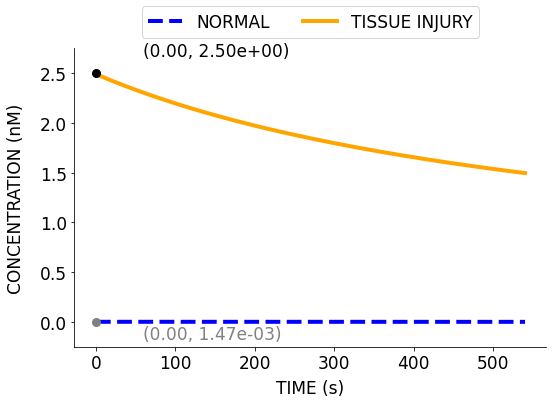

Saved comparison plot for fxa


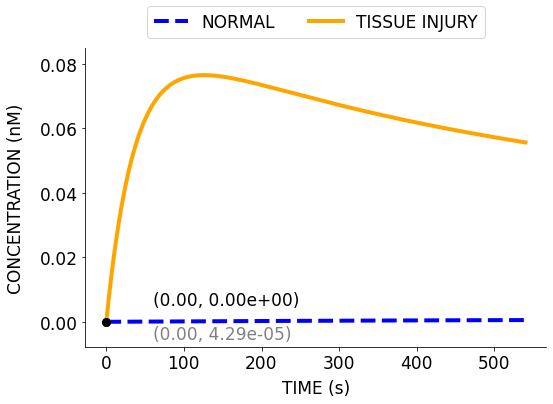

Saved comparison plot for fxa_tfpi


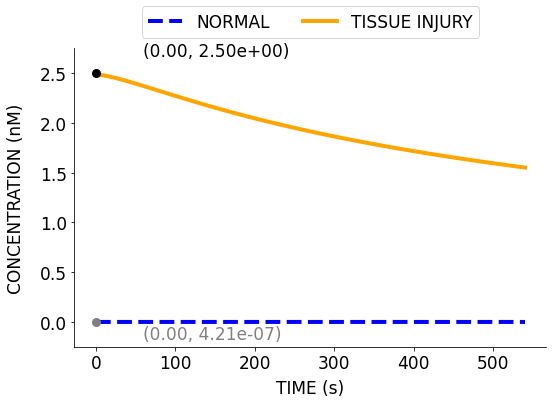

Saved comparison plot for tf_fviia


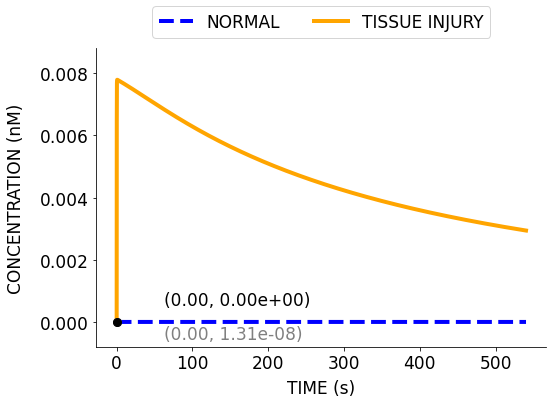

Saved comparison plot for tf_fviia_fxa


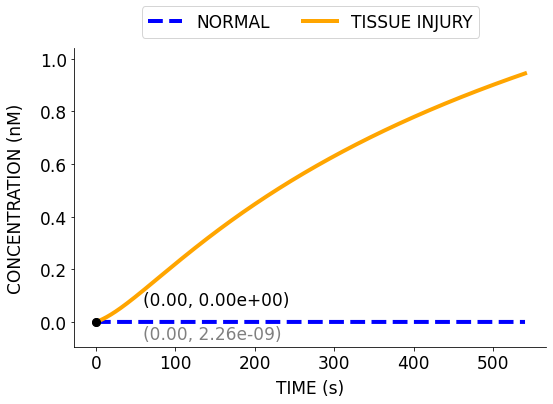

Saved comparison plot for tf_fviia_fxa_tfpi


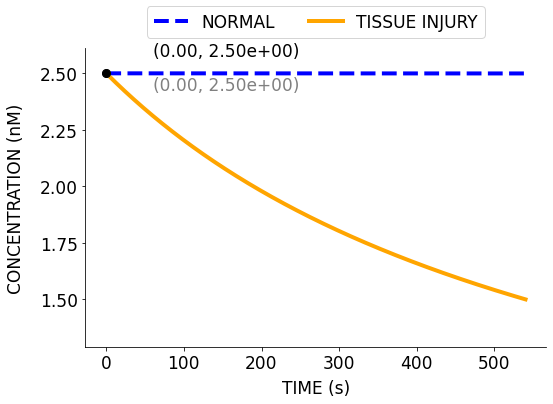

Saved comparison plot for tfpi


In [137]:
import matplotlib.pyplot as plt
import math
import numpy as np
import os

def parse_raw_file(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()

    # Initialize variables
    var_start = data_start = totVariables = None
    variables = []

    # Locate section headers
    for i, line in enumerate(lines):
        if line.strip().startswith("Variables:"):
            var_start = i + 1
        elif line.strip().startswith("Values:"):
            data_start = i + 1
        elif line.strip().startswith("No. Variables:"):
            totVariables = int(line.split(":")[1].strip())

    if None in (var_start, data_start, totVariables):
        raise ValueError(f"Could not parse required sections in {filepath}")

    # Extract variable names
    for line in lines[var_start:var_start + totVariables]:
        parts = line.strip().split()
        if len(parts) == 3:
            _, name, _ = parts
            if name.startswith("v(") and name.endswith(")"):
                name = name[2:-1]
            variables.append(name)

    # Extract numerical data
    raw_data = []
    current_row = []
    for line in lines[data_start:]:
        parts = line.strip().split()
        if not parts:
            continue
        if len(parts) == 1:
            if current_row:
                raw_data.append(current_row)
            current_row = [float(parts[0])]
        elif len(parts) == 2:
            if current_row:
                raw_data.append(current_row)
            current_row = [float(parts[1])]

    if current_row:
        raw_data.append(current_row)

    # Organize data into a dictionary by variable
    data_dict = {}
    for i, var_name in enumerate(variables):
        data_dict[var_name] = [row[0] for row in raw_data[i::len(variables)]]

    return data_dict

# ---------- CONFIG ----------
saveLocation = "C:/Users/gvrqtpi/Desktop/research/"
file1 = os.path.join(saveLocation, "plots/Loop1/verif/archive/iPadtestAutoBase.raw")  # ← file names to compare
file2 = os.path.join(saveLocation, "plots/Loop1/verif/rerun/parsLoop1.txt.raw") # ← file names to compare

# ---------- PROCESS ----------
data1 = parse_raw_file(file1)
data2 = parse_raw_file(file2)

time1 = data1["time"]
time2 = data2["time"]

# Plotting
plt.rcParams.update({'font.size': 17})

shared_vars = [v for v in data1 if v in data2 and v != "time"]

for var in shared_vars:
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(time1, data1[var], label=f"NORMAL", linestyle='--', color='blue', linewidth=4)
    ax.plot(time2, data2[var], label=f"TISSUE INJURY", color='orange', linewidth=4)

    # Compute dynamic offsets based on data range
    x_range = max(time1) - min(time1)
    y_range = max(data1[var] + data2[var]) - min(data1[var] + data2[var])
#     x_offset = x_range * 0.066  # 5% of x range
#     y_offset = y_range * 3  # 7% of y range
    x_offset = 47  # 5% of x range
    y_offset = 17  # 7% of y range

    # Add first point markers
    ax.plot(time1[0], data1[var][0], marker='o', color='gray', markersize=8, zorder=5)
    ax.plot(time2[0], data2[var][0], marker='o', color='black', markersize=8, zorder=5)

    
#     plt.text(time2[0] + x_offset, data2[var][0] - y_offset, f"({time2[0]:.2f}, {data2[var][0]:.2e})") # Adjust as needed for positioning

#     ax.text(time1[0] + x_offset, data1[var][0] + y_offset, f"({time1[0]:.2f}, {data1[var][0]:.2e})", 
#             ha='left', va='top', color='gray', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round,pad=0.2', alpha=0.7))

#     ax.text(time2[0] + x_offset, data2[var][0] - y_offset, f"({time2[0]:.2f}, {data2[var][0]:.2e})", 
#             ha='left', va='bottom', color='black', bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.2', alpha=0.7))

#     # Use ax.annotate instead of ax.text to avoid overlapping
    ax.annotate(f"({time1[0]:.2f}, {data1[var][0]:.2e})", 
                xy=(time1[0], data1[var][0]), 
                xytext=(x_offset, -y_offset),  # Offset in points
                textcoords="offset points", 
                color='gray')#,
#                 bbox=dict(facecolor='none', edgecolor='none', boxstyle='round,pad=0.2', alpha=0.7))

    ax.annotate(f"({time2[0]:.2f}, {data2[var][0]:.2e})", 
                xy=(time2[0], data2[var][0]), 
                xytext=(x_offset, y_offset),  # Negative offset for the second label
                textcoords="offset points", 
                color='black') #,
#                 bbox=dict(facecolor='none', edgecolor='none', boxstyle='round,pad=0.2', alpha=0.7))

    ax.set_xlabel("TIME (s)", labelpad=7)
    ax.set_ylabel("CONCENTRATION (nM)", labelpad=15)
    
    # Limit the number of y-axis ticks
    plt.locator_params(axis='y', nbins=6, prune=None)

    # Dynamically calculate axis limits
    all_values = data1[var] + data2[var]
    min_val = min(all_values)
    max_val = max(all_values)
    range_val = max_val - min_val

    if range_val == 0:
        buffer = abs(min_val * 0.01) if min_val != 0 else 0.1
        lower_lim = min_val - buffer
        upper_lim = max_val + buffer
    else:
        if min_val > 0:
            magnitude = 10 ** math.floor(math.log10(range_val))
            tick_step = magnitude / 10
        else:
            tick_step = 0.001

        lower_lim = math.floor(min_val / tick_step) * tick_step
        upper_lim = math.ceil(max_val / tick_step) * tick_step

        buffer = (upper_lim - lower_lim) * 0.1
        lower_lim -= buffer
        upper_lim += buffer

    ax.set_ylim(lower_lim, upper_lim)

    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.17), ncol=2)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(os.path.join(saveLocation, f"{var}_comparison.png"), dpi=300)
    plt.show()
    plt.close(fig)

    print(f"Saved comparison plot for {var}")


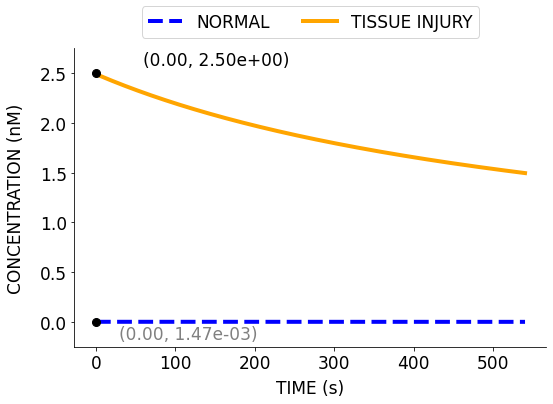

Saved comparison plot for fxa


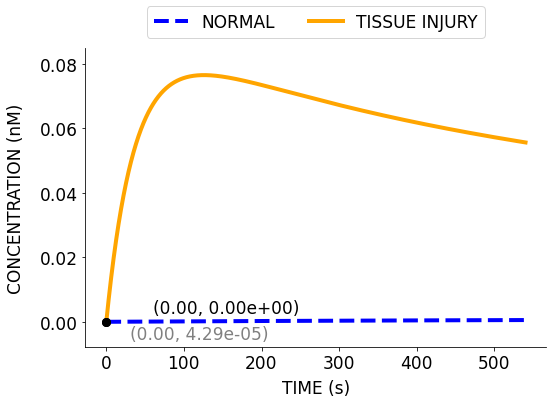

Saved comparison plot for fxa_tfpi


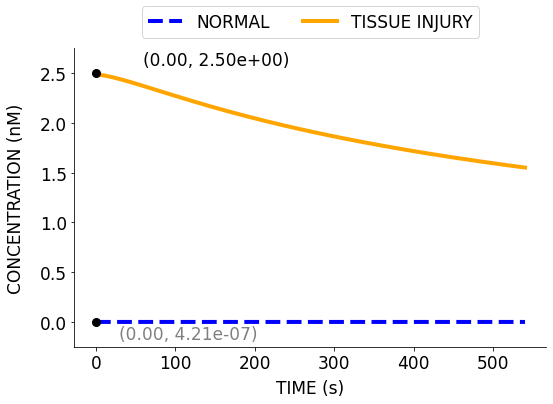

Saved comparison plot for tf_fviia


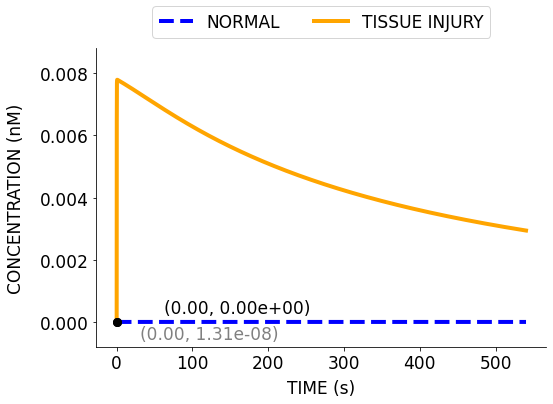

Saved comparison plot for tf_fviia_fxa


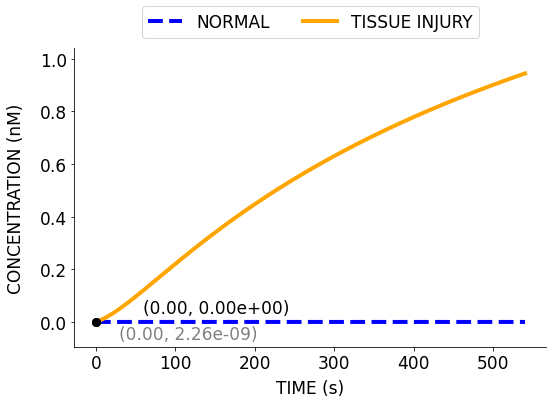

Saved comparison plot for tf_fviia_fxa_tfpi


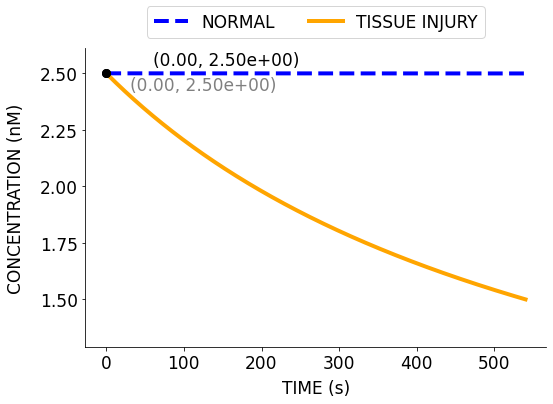

Saved comparison plot for tfpi


In [148]:
import matplotlib.pyplot as plt
import math
import numpy as np
import os

def parse_raw_file(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()

    # Initialize variables
    var_start = data_start = totVariables = None
    variables = []

    # Locate section headers
    for i, line in enumerate(lines):
        if line.strip().startswith("Variables:"):
            var_start = i + 1
        elif line.strip().startswith("Values:"):
            data_start = i + 1
        elif line.strip().startswith("No. Variables:"):
            totVariables = int(line.split(":")[1].strip())

    if None in (var_start, data_start, totVariables):
        raise ValueError(f"Could not parse required sections in {filepath}")

    # Extract variable names
    for line in lines[var_start:var_start + totVariables]:
        parts = line.strip().split()
        if len(parts) == 3:
            _, name, _ = parts
            if name.startswith("v(") and name.endswith(")"):
                name = name[2:-1]
            variables.append(name)

    # Extract numerical data
    raw_data = []
    current_row = []
    for line in lines[data_start:]:
        parts = line.strip().split()
        if not parts:
            continue
        if len(parts) == 1:
            if current_row:
                raw_data.append(current_row)
            current_row = [float(parts[0])]
        elif len(parts) == 2:
            if current_row:
                raw_data.append(current_row)
            current_row = [float(parts[1])]

    if current_row:
        raw_data.append(current_row)

    # Organize data into a dictionary by variable
    data_dict = {}
    for i, var_name in enumerate(variables):
        data_dict[var_name] = [row[0] for row in raw_data[i::len(variables)]]

    return data_dict

# ---------- CONFIG ----------
saveLocation = "C:/Users/gvrqtpi/Desktop/research/"
file1 = os.path.join(saveLocation, "plots/Loop1/verif/archive/iPadtestAutoBase.raw")  # ← file names to compare
file2 = os.path.join(saveLocation, "plots/Loop1/verif/rerun/parsLoop1.txt.raw") # ← file names to compare

# ---------- PROCESS ----------
data1 = parse_raw_file(file1)
data2 = parse_raw_file(file2)

time1 = data1["time"]
time2 = data2["time"]

# Plotting
plt.rcParams.update({'font.size': 17})

shared_vars = [v for v in data1 if v in data2 and v != "time"]

for var in shared_vars:
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(time1, data1[var], label=f"NORMAL", linestyle='--', color='blue', linewidth=4)
    ax.plot(time2, data2[var], label=f"TISSUE INJURY", color='orange', linewidth=4)

    # Compute dynamic offsets based on data range
    x_range = max(time1) - min(time1)
    y_range = max(data1[var] + data2[var]) - min(data1[var] + data2[var])
    x_offset = 45  # 5% of x range
    y_offset = 17  # 7% of y range

    # Get the first points
    first_point_time1 = time1[0]
    first_point_data1 = data1[var][0]
    first_point_time2 = time2[0]
    first_point_data2 = data2[var][0]

    # Calculate the distance between the first points
    x_diff = abs(first_point_time1 - first_point_time2)
    y_diff = abs(first_point_data1 - first_point_data2)

    # If the points are very close, increase the offset to avoid overlap
    if x_diff < x_offset and y_diff < y_offset:
        x_offset = 47 # x_range * 0.15  # Increase x offset
        y_offset = 17 # y_range * 5  # Increase y offset

    # Add first point markers
    ax.plot(time1[0], data1[var][0], marker='o', color='black', markersize=8, zorder=5)
    ax.plot(time2[0], data2[var][0], marker='o', color='black', markersize=8, zorder=5)

    # Annotate the first points with dynamic offsets
    ax.annotate(f"({time1[0]:.2f}, {data1[var][0]:.2e})", 
                xy=(time1[0], data1[var][0]), 
                xytext=(0.5*x_offset, -y_offset),  # Offset in points
                textcoords="offset points", 
                color='gray')
    
    ax.annotate(f"({time2[0]:.2f}, {data2[var][0]:.2e})", 
                xy=(time2[0], data2[var][0]), 
                xytext=(x_offset, 0.5*y_offset),  # Negative offset for the second label
                textcoords="offset points", 
                color='black')
    
    ax.set_xlabel("TIME (s)", labelpad=7)
    ax.set_ylabel("CONCENTRATION (nM)", labelpad=15)
    
    # Limit the number of y-axis ticks
    plt.locator_params(axis='y', nbins=6, prune=None)

    # Dynamically calculate axis limits
    all_values = data1[var] + data2[var]
    min_val = min(all_values)
    max_val = max(all_values)
    range_val = max_val - min_val

    if range_val == 0:
        buffer = abs(min_val * 0.01) if min_val != 0 else 0.1
        lower_lim = min_val - buffer
        upper_lim = max_val + buffer
    else:
        if min_val > 0:
            magnitude = 10 ** math.floor(math.log10(range_val))
            tick_step = magnitude / 10
        else:
            tick_step = 0.001

        lower_lim = math.floor(min_val / tick_step) * tick_step
        upper_lim = math.ceil(max_val / tick_step) * tick_step

        buffer = (upper_lim - lower_lim) * 0.1
        lower_lim -= buffer
        upper_lim += buffer

    ax.set_ylim(lower_lim, upper_lim)

    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.17), ncol=2)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(os.path.join(saveLocation, f"{var}_comparison.png"), dpi=300)
    plt.show()
    plt.close(fig)

    print(f"Saved comparison plot for {var}")
